# Clusterização temática de projetos científicos com BERTimbau, NER e representação híbrida

Este notebook desenvolve uma abordagem de clusterização temática para projetos científicos e tecnológicos a partir de seus títulos e descrições públicas.

A metodologia combina técnicas de Processamento de Linguagem Natural e Aprendizado de Máquina, incluindo:

- limpeza e preparação textual;
- análise exploratória com TF-IDF;
- criação de labels temáticas;
- treinamento de um modelo NER personalizado com spaCy;
- geração de embeddings semânticos com BERTimbau;
- construção de uma representação híbrida;
- clusterização com KMeans;
- interpretação dos clusters com termos, entidades e títulos representativos.

A versão final utilizada neste notebook é a **V3.1**, resultado de sucessivas auditorias das labels e do cluster residual.

## 1. Objetivo

O objetivo principal deste trabalho é agrupar projetos científicos em temas semelhantes a partir de seus textos públicos.

Diferentemente de uma classificação supervisionada tradicional, aqui não temos uma coluna oficial de categoria temática. Por isso, o problema é tratado como uma tarefa exploratória de clusterização.

A estratégia adotada foi combinar três tipos de informação:

1. **BERTimbau**, para capturar o significado semântico dos textos;
2. **TF-IDF/SVD**, para capturar termos técnicos relevantes;
3. **NER personalizado**, para inserir conhecimento de domínio por meio de labels temáticas.

A clusterização final será interpretada com apoio de:

- termos TF-IDF mais importantes por cluster;
- entidades temáticas extraídas pelo NER;
- títulos representativos próximos aos centroides;
- visualizações com PCA e t-SNE.

## 2. Imports e configuração do ambiente

Nesta seção, carregamos as bibliotecas necessárias e definimos parâmetros gerais do notebook.

O notebook foi pensado para rodar no Kaggle, utilizando o dataset adicionado manualmente na aba de inputs.

In [1]:
# ============================================================
# IMPORTS GERAIS
# ============================================================

import os
import re
import gc
import shutil
import random
import warnings
import unicodedata

from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# IMPORTS DE NLP, MACHINE LEARNING E DEEP LEARNING
# ============================================================

import torch

from transformers import AutoTokenizer, AutoModel

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from spacy.scorer import Scorer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

In [3]:
# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", DEVICE)

Dispositivo utilizado: cuda


In [4]:
# ============================================================
# CONFIGURAÇÕES DO PROJETO
# ============================================================

NOME_MODELO_BERT = "neuralmind/bert-base-portuguese-cased"

MAX_LEN_BERT = 256
BATCH_SIZE_BERT = 16

N_EPOCHS_NER = 25
DROPOUT_NER = 0.25

PESO_BERT_FINAL = 1.0
PESO_TFIDF_FINAL = 0.8
PESO_NER_FINAL = 1.3

K_FINAL = 20

OUTPUT_DIR = "/kaggle/working/resultados_finais_v31"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Modelo BERT:", NOME_MODELO_BERT)
print("MAX_LEN_BERT:", MAX_LEN_BERT)
print("BATCH_SIZE_BERT:", BATCH_SIZE_BERT)
print("K final:", K_FINAL)
print("Diretório de saída:", OUTPUT_DIR)

Modelo BERT: neuralmind/bert-base-portuguese-cased
MAX_LEN_BERT: 256
BATCH_SIZE_BERT: 16
K final: 20
Diretório de saída: /kaggle/working/resultados_finais_v31


## 3. Carregamento da base de dados

A base contém textos de projetos científicos e tecnológicos.

As colunas utilizadas são:

- `Título_Público`;
- `Descricao_pública`.

Como o dataset foi adicionado manualmente no Kaggle, o código abaixo procura automaticamente o arquivo `dadosTextosCientificos.tsv` dentro da pasta `/kaggle/input`.

Caso o caminho do arquivo seja diferente, basta alterar manualmente a variável `CAMINHO_DATASET`.

In [5]:
# ============================================================
# BUSCA AUTOMÁTICA DO ARQUIVO NO KAGGLE
# ============================================================

def encontrar_arquivo_dataset(
    nome_arquivo="dadosTextosCientificos.tsv",
    pasta_base="/kaggle/input"
):
    """
    Procura o arquivo do dataset dentro da pasta de inputs do Kaggle.
    """

    caminhos_encontrados = []

    for raiz, _, arquivos in os.walk(pasta_base):
        for arquivo in arquivos:
            if arquivo == nome_arquivo:
                caminhos_encontrados.append(
                    os.path.join(raiz, arquivo)
                )

    if len(caminhos_encontrados) == 0:
        return None

    return caminhos_encontrados[0]


CAMINHO_DATASET = encontrar_arquivo_dataset()

print("Caminho encontrado:")
print(CAMINHO_DATASET)

Caminho encontrado:
/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv


In [6]:
# ============================================================
# CARREGAMENTO DO DATASET
# ============================================================

if CAMINHO_DATASET is None:
    raise FileNotFoundError(
        "O arquivo dadosTextosCientificos.tsv não foi encontrado em /kaggle/input. "
        "Verifique se o dataset foi adicionado manualmente ao notebook."
    )

df_original = pd.read_csv(
    CAMINHO_DATASET,
    sep="\t",
    encoding="latin-1"
)

print("Formato original da base:")
print(df_original.shape)

print("\nColunas encontradas:")
print(df_original.columns.tolist())

display(df_original.head())

Formato original da base:
(2725, 2)

Colunas encontradas:
['Título_Público', 'Descricao_pública']


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...


In [7]:
# ============================================================
# VALIDAÇÃO DAS COLUNAS ESPERADAS
# ============================================================

colunas_esperadas = [
    "Título_Público",
    "Descricao_pública"
]

colunas_ausentes = [
    coluna for coluna in colunas_esperadas
    if coluna not in df_original.columns
]

if len(colunas_ausentes) > 0:
    raise ValueError(
        "As seguintes colunas esperadas não foram encontradas: "
        + ", ".join(colunas_ausentes)
    )

print("Todas as colunas esperadas foram encontradas.")

Todas as colunas esperadas foram encontradas.


## 4. Visão inicial da base

Antes da limpeza textual, vamos verificar:

- quantidade de registros;
- valores ausentes;
- exemplos de títulos e descrições;
- tamanho aproximado dos textos.

Essa etapa ajuda a entender a qualidade inicial da base.

In [8]:
# ============================================================
# VISÃO INICIAL DA BASE
# ============================================================

print("Quantidade de registros:")
print(len(df_original))

print("\nValores ausentes por coluna:")
display(df_original[colunas_esperadas].isna().sum().reset_index().rename(
    columns={
        "index": "coluna",
        0: "quantidade_ausentes"
    }
))

print("\nAmostra de registros:")
display(
    df_original[colunas_esperadas].sample(
        n=min(10, len(df_original)),
        random_state=RANDOM_STATE
    )
)

Quantidade de registros:
2725

Valores ausentes por coluna:


,coluna,quantidade_ausentes
0,Título_Público,3
1,Descricao_pública,4



Amostra de registros:


,Título_Público,Descricao_pública
2228,Desenvolvimento de Aglomerante a Frio para min...,Desenvolvimento de Aglomerante a Frio para min...
1344,TRACK SYSTEM,Desenvolver uma nova plataforma de Hardware e ...
1418,LUMINÁRIAS URBANAS INTELIGENTES E SUSTENTÁVEIS,O projeto busca transformar a iluminação públi...
1833,Conversor do tipo filtro ativo para redução de...,"Este projeto, executado pela Unidade Embrapii ..."
605,Desenvolvimento de Microstent,Desenvolver nova geometria de Microstent.
2142,Le Mans,Desenvolvimento e validação laboratorial de um...
291,Yágua Utilities 4.0,Este projeto tem como objetivo gerar component...
1058,Operações de Produção Inteligentes e Integrada...,Este projeto pode ser considerado como uma seg...
1134,Desenvolvimento de Dispositivo Localizador de ...,Desenvolvimento de um dispositivo localizador ...
2364,Magnetização da água e uso como água de amassa...,Considerando o desempenho da água magnetizada ...


In [9]:
# ============================================================
# CRIAÇÃO DE UMA CÓPIA PADRONIZADA DA BASE
# ============================================================

df = df_original[colunas_esperadas].copy()

df = df.rename(
    columns={
        "Título_Público": "titulo",
        "Descricao_pública": "descricao"
    }
)

df["titulo"] = df["titulo"].fillna("").astype(str)
df["descricao"] = df["descricao"].fillna("").astype(str)

df["titulo"] = df["titulo"].str.strip()
df["descricao"] = df["descricao"].str.strip()

print("Formato da base padronizada:")
print(df.shape)

display(df.head())

Formato da base padronizada:
(2725, 2)


,titulo,descricao
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...


## 5. Funções auxiliares iniciais

As funções abaixo serão usadas ao longo do notebook para normalização textual, remoção de acentos e limpeza básica.

A normalização será importante para:

- análise de termos;
- criação das labels;
- busca de entidades por expressões regulares;
- comparação entre versões.

In [10]:
# ============================================================
# FUNÇÕES DE NORMALIZAÇÃO TEXTUAL
# ============================================================

def remover_acentos(texto):
    """
    Remove acentos de uma string.
    """

    texto = str(texto)

    texto_normalizado = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto_sem_acentos = "".join(
        caractere
        for caractere in texto_normalizado
        if not unicodedata.combining(caractere)
    )

    return texto_sem_acentos


def normalizar_texto_para_analise(texto):
    """
    Normaliza texto para análises baseadas em busca de termos.
    """

    texto = str(texto).lower()
    texto = remover_acentos(texto)

    texto = re.sub(r"\s+", " ", texto)
    texto = texto.strip()

    return texto


def limpar_espacos(texto):
    """
    Remove espaços repetidos e quebras de linha excessivas.
    """

    texto = str(texto)
    texto = texto.replace("\n", " ")
    texto = texto.replace("\r", " ")
    texto = re.sub(r"\s+", " ", texto)
    texto = texto.strip()

    return texto

In [11]:
# ============================================================
# STOPWORDS PERSONALIZADAS PARA TF-IDF
# ============================================================

stopwords_portugues_refinadas = [
    "a", "o", "os", "as", "um", "uma", "uns", "umas",
    "de", "da", "do", "das", "dos",
    "em", "no", "na", "nos", "nas",
    "por", "para", "com", "sem", "sob", "sobre",
    "e", "ou", "mas", "que", "se",
    "ao", "aos", "à", "às",
    "como", "entre", "até", "após",
    "ser", "sendo", "foi", "são", "sera", "será",
    "este", "esta", "estes", "estas",
    "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas",
    "projeto", "pesquisa", "desenvolvimento",
    "objetivo", "objetiva", "objetivos",
    "desenvolver", "desenvolvimento",
    "solucao", "solução",
    "produto", "produtos",
    "processo", "processos",
    "tecnologia", "tecnologias",
    "novo", "nova", "novos", "novas",
    "uso", "utilizacao", "utilização",
    "aplicacao", "aplicação",
    "partir", "meio", "forma",
    "empresa", "empresas",
    "base", "bases",
    "atraves", "através",
    "visando", "permitir", "realizar",
    "bem", "tambem", "também",
    "deste", "desta", "nesse", "nessa",
    "p&d", "pd"
]

print("Quantidade de stopwords personalizadas:")
print(len(stopwords_portugues_refinadas))

Quantidade de stopwords personalizadas:
101


# 6. Preparação textual

Nesta etapa, vamos construir as colunas textuais que serão usadas ao longo do projeto.

Serão criadas três versões principais do texto:

1. `texto_original`: título e descrição unidos uma única vez;
2. `texto_titulo_reforcado`: título repetido antes da descrição, para dar mais peso ao título;
3. `texto`: versão principal usada nas análises iniciais.

O título costuma carregar muita informação temática. Por isso, em etapas posteriores, a versão com título reforçado será usada para gerar embeddings com BERTimbau.

In [12]:
# ============================================================
# CRIAÇÃO DAS COLUNAS TEXTUAIS
# ============================================================

df_textos = df.copy()

df_textos["titulo"] = df_textos["titulo"].apply(limpar_espacos)
df_textos["descricao"] = df_textos["descricao"].apply(limpar_espacos)

df_textos["texto_original"] = (
    df_textos["titulo"]
    + ". "
    + df_textos["descricao"]
).apply(limpar_espacos)

df_textos["texto_titulo_reforcado"] = (
    df_textos["titulo"]
    + ". "
    + df_textos["titulo"]
    + ". "
    + df_textos["descricao"]
).apply(limpar_espacos)

# Texto principal inicial.
df_textos["texto"] = df_textos["texto_original"]

df_textos["qtd_caracteres"] = df_textos["texto"].str.len()
df_textos["qtd_palavras"] = df_textos["texto"].apply(
    lambda texto: len(str(texto).split())
)

print("Formato após criação dos textos:")
print(df_textos.shape)

display(
    df_textos[
        [
            "titulo",
            "descricao",
            "texto_original",
            "texto_titulo_reforcado",
            "qtd_palavras"
        ]
    ].head()
)

Formato após criação dos textos:
(2725, 7)


,titulo,descricao,texto_original,texto_titulo_reforcado,qtd_palavras
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...,Açúcar de frutas e aplicação em bolos como sub...,Açúcar de frutas e aplicação em bolos como sub...,102
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...,Desenvolver uma linha de farofas com castanhas...,Desenvolver uma linha de farofas com castanhas...,143
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...,Desenvolvimento de cobertura líquida para sorv...,Desenvolvimento de cobertura líquida para sorv...,118
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...,Desenvolvimento de conserva de tomate cereja. ...,Desenvolvimento de conserva de tomate cereja. ...,137
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...,Desenvolvimento de massa alimentícia enriqueci...,Desenvolvimento de massa alimentícia enriqueci...,187


## 6.1 Remoção de textos vazios

Vamos remover registros em que o texto final ficou vazio ou praticamente sem conteúdo.

Essa etapa é conservadora, pois o objetivo é não eliminar projetos válidos por engano.

In [13]:
# ============================================================
# REMOÇÃO DE TEXTOS VAZIOS
# ============================================================

qtd_antes_textos_vazios = len(df_textos)

df_textos = df_textos[
    df_textos["texto"].str.strip().str.len() > 0
].copy()

qtd_depois_textos_vazios = len(df_textos)

print("Quantidade antes da remoção de textos vazios:")
print(qtd_antes_textos_vazios)

print("\nQuantidade depois:")
print(qtd_depois_textos_vazios)

print("\nRemovidos:")
print(qtd_antes_textos_vazios - qtd_depois_textos_vazios)

Quantidade antes da remoção de textos vazios:
2725

Quantidade depois:
2725

Removidos:
0


## 6.2 Remoção de duplicatas exatas

Como estamos trabalhando com clusterização, duplicatas exatas podem distorcer os agrupamentos.

Nesta etapa, removemos textos exatamente iguais.

In [14]:
# ============================================================
# REMOÇÃO DE DUPLICATAS EXATAS
# ============================================================

qtd_antes_duplicatas = len(df_textos)

qtd_duplicatas_exatas = df_textos.duplicated(
    subset=["texto"]
).sum()

df_textos = df_textos.drop_duplicates(
    subset=["texto"]
).copy()

qtd_depois_duplicatas = len(df_textos)

print("Duplicatas exatas encontradas:")
print(qtd_duplicatas_exatas)

print("\nQuantidade antes:")
print(qtd_antes_duplicatas)

print("\nQuantidade depois:")
print(qtd_depois_duplicatas)

print("\nRemovidos:")
print(qtd_antes_duplicatas - qtd_depois_duplicatas)

Duplicatas exatas encontradas:
4

Quantidade antes:
2725

Quantidade depois:
2721

Removidos:
4


## 6.3 Estatísticas dos textos

Agora vamos observar o tamanho dos textos.

Essa etapa ajuda a entender se estamos lidando com textos longos, resumos curtos ou descrições muito pequenas.

In [15]:
# ============================================================
# ESTATÍSTICAS DE TAMANHO DOS TEXTOS
# ============================================================

df_estatisticas_texto = df_textos[
    [
        "qtd_caracteres",
        "qtd_palavras"
    ]
].describe().T

display(df_estatisticas_texto)

print("Menores textos por quantidade de palavras:")
display(
    df_textos.sort_values("qtd_palavras")[
        [
            "titulo",
            "qtd_palavras",
            "texto"
        ]
    ].head(20)
)

print("\nMaiores textos por quantidade de palavras:")
display(
    df_textos.sort_values("qtd_palavras", ascending=False)[
        [
            "titulo",
            "qtd_palavras",
            "texto"
        ]
    ].head(10)
)

,count,mean,std,min,25%,50%,75%,max
qtd_caracteres,2721.0,411.239618,398.581927,1.0,167.0,278.0,508.0,3115.0
qtd_palavras,2721.0,59.467475,58.954224,1.0,23.0,40.0,74.0,467.0


Menores textos por quantidade de palavras:


,titulo,qtd_palavras,texto
539,,1,.
2384,.,2,.. .
2108,Biofiller,2,Biofiller. Biofiller
2348,FleetSense,2,FleetSense. Confidencial
2358,PLATAFORMA COVID-19,3,PLATAFORMA COVID-19. --
2135,Gaia,3,Gaia. A definir
1871,a definir,4,a definir. a definir
1936,Gênesis II,4,Gênesis II. Gênesis II
192,PCS,4,PCS. Sistema PCS inteligente.
2115,Compostos MP-R,4,Compostos MP-R. Compostos MP-R.



Maiores textos por quantidade de palavras:


,titulo,qtd_palavras,texto
1269,DESENVOLVIMENTO DE ESTRATÉGIAS PARA REUTILIZAÇ...,467,DESENVOLVIMENTO DE ESTRATÉGIAS PARA REUTILIZAÇ...
1652,FLOW recomendação inteligente aplicada ao merc...,459,FLOW recomendação inteligente aplicada ao merc...
1700,Produção de bioplástico a partir de resíduos d...,450,Produção de bioplástico a partir de resíduos d...
1694,Desenvolvimento de geleia de pitaya convencion...,448,Desenvolvimento de geleia de pitaya convencion...
1688,Adaptação e validação da tecnologia de espectr...,425,Adaptação e validação da tecnologia de espectr...
1689,Aperfeiçoamento do desenvolvimento da platafor...,422,Aperfeiçoamento do desenvolvimento da platafor...
1827,Desenvolvimento de hibridoma para produção de ...,422,Desenvolvimento de hibridoma para produção de ...
1698,Desenvolvimento e avaliação da eficiência de f...,397,Desenvolvimento e avaliação da eficiência de f...
2722,Talhonameno Ótimo Klabin,388,Talhonameno Ótimo Klabin. A Klabin S/A é uma e...
2577,EMBRAPII: Fragilização Hidrogênio Titânio,386,EMBRAPII: Fragilização Hidrogênio Titânio. O t...


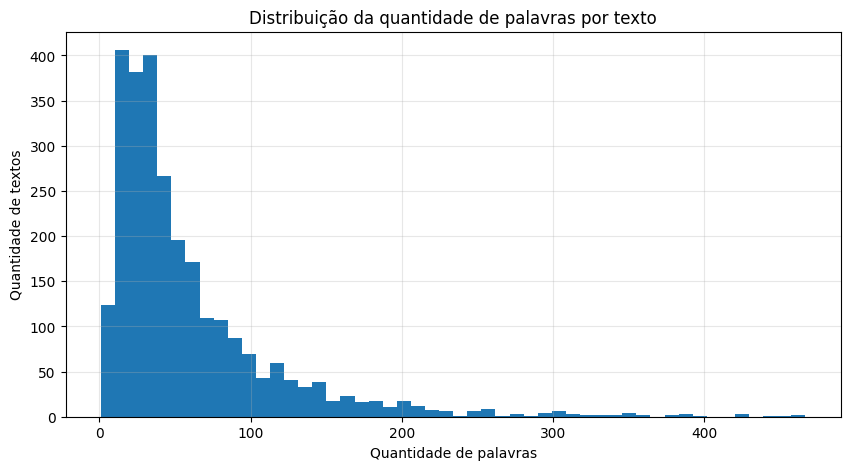

In [16]:
# ============================================================
# HISTOGRAMA DO TAMANHO DOS TEXTOS
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df_textos["qtd_palavras"],
    bins=50
)

plt.title("Distribuição da quantidade de palavras por texto")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Quantidade de textos")
plt.grid(True, alpha=0.3)

plt.show()

# 7. Filtro conservador de ruídos

Durante a análise inicial, foram identificados alguns textos com pouca informação útil para clusterização.

Para evitar remover projetos válidos, usamos um filtro conservador.

Serão removidos apenas textos que se enquadram em pelo menos uma das situações abaixo:

- texto extremamente curto;
- descrição explicitamente não divulgada;
- projeto cancelado, pendente ou sem conteúdo informativo.

Textos apenas genéricos ou interdisciplinares serão mantidos.

In [17]:
# ============================================================
# FUNÇÕES PARA IDENTIFICAÇÃO CONSERVADORA DE RUÍDOS
# ============================================================

def contem_padrao(texto, padroes):
    """
    Verifica se o texto contém algum padrão de uma lista.
    """

    texto_norm = normalizar_texto_para_analise(texto)

    for padrao in padroes:
        if re.search(padrao, texto_norm):
            return True

    return False


# Expressões explícitas de descrição não divulgada.
# Esta lista é conservadora: não remove textos apenas por serem curtos ou genéricos.
padroes_descricao_nao_divulgada = [
    r"(confidencial\s+e\s+nao\s+pode\s+ser\s+divulgad[oa])",
    r"(optamos\s+por\s+nao\s+apresentar)",
    r"\bnao divulgado\b",
    r"\bnao divulgada\b"
]

# Expressões explícitas de projeto cancelado ou pendente.
# Evita remover qualquer texto que contenha palavras genéricas como "indisponível" ou "pendente" fora desse contexto.
padroes_cancelado_pendente = [
    r"\bprojeto\s+cancelado\b",
    r"\bcancelado\b",
    r"\bpendente\s+definicao\b",
    r"\bpendente\s+de\s+definicao\b",
    r"\bpendente\s+definição\b",
    r"\bpendente\s+de\s+definição\b"
]


def identificar_ruido_textual(linha):
    """
    Identifica ruídos textuais de forma conservadora.

    O mesmo critério usado no notebook de testes foi mantido:
    textos extremamente curtos são apenas os textos com 4 palavras ou menos.
    """

    texto = linha["texto"]
    descricao = linha["descricao"]
    qtd_palavras = linha["qtd_palavras"]

    texto_extremamente_curto = qtd_palavras <= 4

    descricao_nao_divulgada = contem_padrao(
        descricao,
        padroes_descricao_nao_divulgada
    )

    texto_cancelado_ou_pendente = contem_padrao(
        texto,
        padroes_cancelado_pendente
    )

    ruido_forte = (
        texto_extremamente_curto
        or descricao_nao_divulgada
        or texto_cancelado_ou_pendente
    )

    return pd.Series({
        "texto_extremamente_curto": texto_extremamente_curto,
        "descricao_nao_divulgada": descricao_nao_divulgada,
        "texto_cancelado_ou_pendente": texto_cancelado_ou_pendente,
        "ruido_forte": ruido_forte
    })


In [18]:
# ============================================================
# APLICAÇÃO DO FILTRO DE RUÍDOS
# ============================================================

df_ruidos = df_textos.apply(
    identificar_ruido_textual,
    axis=1
)

df_textos = pd.concat(
    [
        df_textos,
        df_ruidos
    ],
    axis=1
)

df_resumo_ruidos = pd.DataFrame([
    {
        "criterio": "Texto extremamente curto",
        "quantidade": int(df_textos["texto_extremamente_curto"].sum())
    },
    {
        "criterio": "Descrição explicitamente não divulgada",
        "quantidade": int(df_textos["descricao_nao_divulgada"].sum())
    },
    {
        "criterio": "Texto cancelado ou pendente",
        "quantidade": int(df_textos["texto_cancelado_ou_pendente"].sum())
    },
    {
        "criterio": "Ruído forte final",
        "quantidade": int(df_textos["ruido_forte"].sum())
    }
])

df_resumo_ruidos["percentual"] = (
    df_resumo_ruidos["quantidade"]
    / len(df_textos)
    * 100
).round(2)

display(df_resumo_ruidos)

print("Exemplos marcados como ruído forte:")
display(
    df_textos[df_textos["ruido_forte"]][
        [
            "titulo",
            "descricao",
            "qtd_palavras",
            "texto_extremamente_curto",
            "descricao_nao_divulgada",
            "texto_cancelado_ou_pendente",
            "texto"
        ]
    ].head(30)
)

,criterio,quantidade,percentual
0,Texto extremamente curto,10,0.37
1,Descrição explicitamente não divulgada,7,0.26
2,Texto cancelado ou pendente,3,0.11
3,Ruído forte final,19,0.70


Exemplos marcados como ruído forte:


,titulo,descricao,qtd_palavras,texto_extremamente_curto,descricao_nao_divulgada,texto_cancelado_ou_pendente,texto
192,PCS,Sistema PCS inteligente.,4,True,False,False,PCS. Sistema PCS inteligente.
429,PROJETO CANCELADO -,PROJETO CANCELADO,5,False,False,True,PROJETO CANCELADO -. PROJETO CANCELADO
491,Pendente definição do cliente,Pendente definição do cliente,8,False,False,True,Pendente definição do cliente. Pendente defini...
539,,,1,True,False,False,.
660,HP - DeepShare 2020,O projeto é confidencial e não pode ser divulgado,13,False,True,False,HP - DeepShare 2020. O projeto é confidencial ...
661,HP - Z@Edge 2020,O projeto é confidencial e não pode ser divulg...,13,False,True,False,HP - Z@Edge 2020. O projeto é confidencial e n...
662,HP - Z@EDGE21,O projeto é confidencial e não pode ser divulgado,12,False,True,False,HP - Z@EDGE21. O projeto é confidencial e não ...
698,MULTI DEVICE DOCK,O projeto é confidencial e não pode ser divulgado,12,False,True,False,MULTI DEVICE DOCK. O projeto é confidencial e ...
737,Prova de Conceito de Computação Ubíqua UBIq (P...,O projeto é confidencial e não pode ser divulg...,18,False,True,False,Prova de Conceito de Computação Ubíqua UBIq (P...
800,UBI -Computação Ubíqua,O projeto é confidencial e não pode ser divulg...,12,False,True,False,UBI -Computação Ubíqua. O projeto é confidenci...


In [19]:
# ============================================================
# BASE FILTRADA FINAL
# ============================================================

qtd_antes_filtro_ruido = len(df_textos)

df_textos_filtrado = df_textos[
    ~df_textos["ruido_forte"]
].copy()

qtd_depois_filtro_ruido = len(df_textos_filtrado)

# Reorganiza o índice para facilitar mapeamentos posteriores.
df_textos_filtrado = df_textos_filtrado.reset_index(drop=True)

print("Quantidade antes do filtro de ruído:")
print(qtd_antes_filtro_ruido)

print("\nQuantidade depois do filtro:")
print(qtd_depois_filtro_ruido)

print("\nTextos removidos:")
print(qtd_antes_filtro_ruido - qtd_depois_filtro_ruido)

print("\nFormato final da base filtrada:")
print(df_textos_filtrado.shape)

display(df_textos_filtrado.head())

Quantidade antes do filtro de ruído:
2721

Quantidade depois do filtro:
2702

Textos removidos:
19

Formato final da base filtrada:
(2702, 11)


,titulo,descricao,texto_original,texto_titulo_reforcado,texto,qtd_caracteres,qtd_palavras,texto_extremamente_curto,descricao_nao_divulgada,texto_cancelado_ou_pendente,ruido_forte
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...,Açúcar de frutas e aplicação em bolos como sub...,Açúcar de frutas e aplicação em bolos como sub...,Açúcar de frutas e aplicação em bolos como sub...,707,102,False,False,False,False
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...,Desenvolver uma linha de farofas com castanhas...,Desenvolver uma linha de farofas com castanhas...,Desenvolver uma linha de farofas com castanhas...,949,143,False,False,False,False
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...,Desenvolvimento de cobertura líquida para sorv...,Desenvolvimento de cobertura líquida para sorv...,Desenvolvimento de cobertura líquida para sorv...,900,118,False,False,False,False
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...,Desenvolvimento de conserva de tomate cereja. ...,Desenvolvimento de conserva de tomate cereja. ...,Desenvolvimento de conserva de tomate cereja. ...,968,137,False,False,False,False
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...,Desenvolvimento de massa alimentícia enriqueci...,Desenvolvimento de massa alimentícia enriqueci...,Desenvolvimento de massa alimentícia enriqueci...,1347,187,False,False,False,False


# 8. Análise exploratória com TF-IDF

Antes de treinar o NER e gerar embeddings com BERTimbau, vamos fazer uma análise exploratória usando TF-IDF.

O TF-IDF ajuda a identificar os termos mais característicos da base.

Essa etapa também orienta a criação e revisão das labels temáticas.

In [20]:
# ============================================================
# FUNÇÃO PARA OBTER TOP TERMOS DE UMA MATRIZ TF-IDF
# ============================================================

def obter_top_termos_tfidf(matriz, termos, top_n=30):
    """
    Calcula os termos com maior peso médio em uma matriz TF-IDF.
    """

    pesos_medios = np.asarray(
        matriz.mean(axis=0)
    ).ravel()

    indices_top = pesos_medios.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "termo": termos[indices_top],
        "peso_tfidf_medio": pesos_medios[indices_top]
    })

In [21]:
# ============================================================
# TF-IDF EXPLORATÓRIO DA BASE COMPLETA
# ============================================================

vectorizer_tfidf_exploratorio = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85
)

matriz_tfidf_exploratoria = vectorizer_tfidf_exploratorio.fit_transform(
    df_textos_filtrado["texto"].tolist()
)

termos_tfidf_exploratorio = np.array(
    vectorizer_tfidf_exploratorio.get_feature_names_out()
)

df_top_termos_tfidf_exploratorio = obter_top_termos_tfidf(
    matriz=matriz_tfidf_exploratoria,
    termos=termos_tfidf_exploratorio,
    top_n=50
)

print("Formato da matriz TF-IDF exploratória:")
print(matriz_tfidf_exploratoria.shape)

display(df_top_termos_tfidf_exploratorio)

Formato da matriz TF-IDF exploratória:
(2702, 6898)


,termo,peso_tfidf_medio
0,sistema,0.025221
1,producao,0.015825
2,software,0.015438
3,dados,0.013324
4,plataforma,0.012863
5,controle,0.012157
6,monitoramento,0.011489
7,sistemas,0.010773
8,tem,0.010168
9,inteligente,0.009300


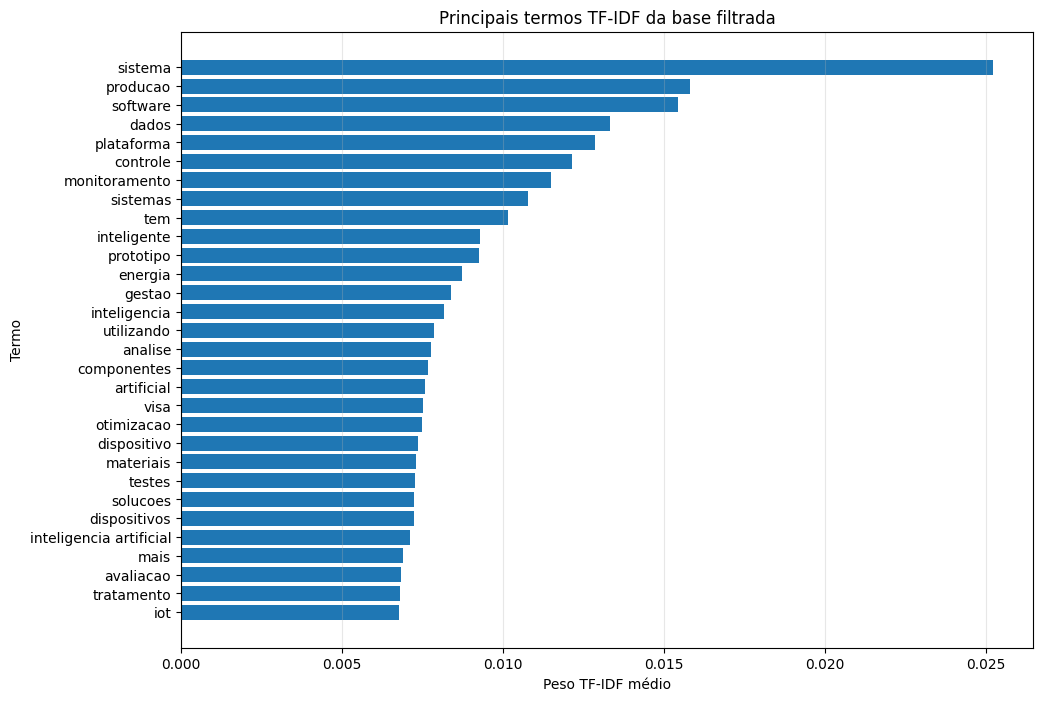

In [22]:
# ============================================================
# GRÁFICO DOS PRINCIPAIS TERMOS TF-IDF
# ============================================================

df_plot_top_tfidf = df_top_termos_tfidf_exploratorio.head(30).sort_values(
    by="peso_tfidf_medio",
    ascending=True
)

plt.figure(figsize=(11, 8))

plt.barh(
    df_plot_top_tfidf["termo"],
    df_plot_top_tfidf["peso_tfidf_medio"]
)

plt.title("Principais termos TF-IDF da base filtrada")
plt.xlabel("Peso TF-IDF médio")
plt.ylabel("Termo")
plt.grid(True, axis="x", alpha=0.3)

plt.show()

## 8.1 Interpretação inicial dos termos

Os principais termos da base indicam que os projetos envolvem temas como:

- software e dados;
- plataformas digitais;
- controle e monitoramento;
- sistemas inteligentes;
- energia;
- materiais;
- resíduos;
- automação;
- equipamentos;
- processos produtivos.

Essa análise confirma que a base é interdisciplinar e possui forte presença de projetos tecnológicos aplicados.

Por isso, apenas embeddings semânticos podem não ser suficientes para gerar clusters interpretáveis.

A etapa seguinte introduz labels temáticas e um modelo NER personalizado para inserir conhecimento de domínio na representação dos textos.

# 9. Funções auxiliares para análise de clusters

As funções abaixo serão usadas posteriormente para interpretar os clusters finais.

Elas permitem calcular:

- termos TF-IDF médios por cluster;
- títulos mais próximos dos centroides;
- resumos interpretáveis dos agrupamentos.

In [23]:
# ============================================================
# TF-IDF MÉDIO POR CLUSTER
# ============================================================

def calcular_tfidf_medio_por_cluster(
    df_base,
    coluna_texto,
    coluna_cluster,
    top_n=20,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
):
    """
    Calcula os termos com maior TF-IDF médio dentro de cada cluster.
    """

    registros = []

    clusters = sorted(
        df_base[coluna_cluster].dropna().unique()
    )

    for cluster_id in clusters:
        df_cluster = df_base[
            df_base[coluna_cluster] == cluster_id
        ]

        if len(df_cluster) < 2:
            continue

        vectorizer = TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            stop_words=stopwords_portugues_refinadas,
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=max_df
        )

        try:
            matriz = vectorizer.fit_transform(
                df_cluster[coluna_texto].tolist()
            )

            termos = np.array(
                vectorizer.get_feature_names_out()
            )

            df_top = obter_top_termos_tfidf(
                matriz=matriz,
                termos=termos,
                top_n=top_n
            )

            for posicao, linha in df_top.reset_index(drop=True).iterrows():
                registros.append({
                    "cluster": cluster_id,
                    "posicao": posicao + 1,
                    "termo": linha["termo"],
                    "peso_tfidf_medio": linha["peso_tfidf_medio"]
                })

        except ValueError:
            continue

    return pd.DataFrame(registros)

In [24]:
# ============================================================
# TÍTULOS MAIS PRÓXIMOS DOS CENTROIDES
# ============================================================

def obter_titulos_proximos_centroides(
    df_base,
    embeddings_cluster,
    kmeans,
    coluna_cluster,
    n=10
):
    """
    Retorna os títulos mais próximos do centroide de cada cluster.
    """

    registros = []

    centros = kmeans.cluster_centers_

    for cluster_id in sorted(df_base[coluna_cluster].unique()):
        indices_cluster = np.where(
            df_base[coluna_cluster].values == cluster_id
        )[0]

        if len(indices_cluster) == 0:
            continue

        embeddings_cluster_local = embeddings_cluster[
            indices_cluster
        ]

        centroide = centros[int(cluster_id)]

        distancias = np.linalg.norm(
            embeddings_cluster_local - centroide,
            axis=1
        )

        ordem = np.argsort(distancias)[:n]

        for posicao, idx_local in enumerate(ordem, start=1):
            idx_global = indices_cluster[idx_local]

            registros.append({
                "cluster": int(cluster_id),
                "posicao": posicao,
                "titulo": df_base.iloc[idx_global]["titulo"],
                "qtd_palavras": df_base.iloc[idx_global]["qtd_palavras"],
                "distancia_centroide": distancias[idx_local]
            })

    return pd.DataFrame(registros)

# 10. Resultado da preparação

Ao final desta etapa, temos a base `df_textos_filtrado`, que será usada nas próximas fases do projeto.

Essa base contém:

- títulos e descrições padronizados;
- textos unidos;
- versão com título reforçado;
- estatísticas de tamanho;
- remoção conservadora de ruídos;
- remoção de duplicatas exatas.

A partir daqui, o notebook passa para a construção das labels V3.1 e treinamento do NER personalizado.

In [25]:
# ============================================================
# RESUMO DA BASE PREPARADA
# ============================================================

df_resumo_preparacao = pd.DataFrame([
    {
        "etapa": "Base original",
        "quantidade_textos": len(df_original)
    },
    {
        "etapa": "Base após preparação e filtro conservador",
        "quantidade_textos": len(df_textos_filtrado)
    }
])

display(df_resumo_preparacao)

print("Colunas disponíveis em df_textos_filtrado:")
print(df_textos_filtrado.columns.tolist())

display(df_textos_filtrado.head())

,etapa,quantidade_textos
0,Base original,2725
1,Base após preparação e filtro conservador,2702


Colunas disponíveis em df_textos_filtrado:
['titulo', 'descricao', 'texto_original', 'texto_titulo_reforcado', 'texto', 'qtd_caracteres', 'qtd_palavras', 'texto_extremamente_curto', 'descricao_nao_divulgada', 'texto_cancelado_ou_pendente', 'ruido_forte']


,titulo,descricao,texto_original,texto_titulo_reforcado,texto,qtd_caracteres,qtd_palavras,texto_extremamente_curto,descricao_nao_divulgada,texto_cancelado_ou_pendente,ruido_forte
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...,Açúcar de frutas e aplicação em bolos como sub...,Açúcar de frutas e aplicação em bolos como sub...,Açúcar de frutas e aplicação em bolos como sub...,707,102,False,False,False,False
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...,Desenvolver uma linha de farofas com castanhas...,Desenvolver uma linha de farofas com castanhas...,Desenvolver uma linha de farofas com castanhas...,949,143,False,False,False,False
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...,Desenvolvimento de cobertura líquida para sorv...,Desenvolvimento de cobertura líquida para sorv...,Desenvolvimento de cobertura líquida para sorv...,900,118,False,False,False,False
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...,Desenvolvimento de conserva de tomate cereja. ...,Desenvolvimento de conserva de tomate cereja. ...,Desenvolvimento de conserva de tomate cereja. ...,968,137,False,False,False,False
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...,Desenvolvimento de massa alimentícia enriqueci...,Desenvolvimento de massa alimentícia enriqueci...,Desenvolvimento de massa alimentícia enriqueci...,1347,187,False,False,False,False


# 11. Construção das labels temáticas V3.1

A etapa central deste projeto foi a criação de labels temáticas para orientar o modelo NER.

A ideia foi usar o NER não apenas para reconhecer entidades tradicionais, como nomes de pessoas ou organizações, mas para reconhecer **indícios temáticos** dentro dos textos.

A versão final das labels, chamada de **V3.1**, foi construída após auditorias sucessivas dos resultados anteriores.

A V3.1 possui 19 labels:

1. Computação, IA e dados;
2. Energia;
3. Resíduos e meio ambiente;
4. Saúde e biotecnologia;
5. Alimentos e agro;
6. Engenharia de materiais;
7. Sistemas, IoT e automação;
8. Automotiva e mobilidade;
9. Petróleo, gás e petroquímica;
10. Química e processos industriais;
11. Construção civil;
12. Software e plataformas digitais;
13. Metrologia, testes e qualidade;
14. Gestão, logística e negócios;
15. Telecomunicações, conectividade e fotônica;
16. Segurança, identificação e autenticação;
17. Mineração e siderurgia;
18. Bioprocessos e fermentação;
19. Manufatura e produção operacional.

In [26]:
# ============================================================
# LABELS TEMÁTICAS FINAIS — V3.1
# Parte 1
# ============================================================

labels_ner_treino_final = {
    "AREA_COMPUTACAO_DADOS": {
        "descricao": "IA, aprendizado de máquina, visão computacional, NLP, OCR, mineração e análise de dados.",
        "termos_referencia": [
            "inteligência artificial", "inteligencia artificial",
            "machine learning",
            "aprendizado de máquina", "aprendizagem de máquina",
            "deep learning", "aprendizado profundo",
            "redes neurais", "rede neural",
            "visão computacional", "visao computacional",
            "processamento de imagens",
            "processamento de linguagem natural",
            "nlp", "ocr",
            "mineração de dados", "mineracao de dados",
            "análise de dados", "analise de dados",
            "ciência de dados", "ciencia de dados",
            "analytics", "big data",
            "classificação de documentos", "classificacao de documentos",
            "extração inteligente", "extracao inteligente",
            "reconhecimento facial",
            "reconhecimento automático", "reconhecimento automatico",
            "recomendação", "recomendacao",
            "modelo preditivo", "modelos preditivos"
        ]
    },

    "AREA_ENERGIA": {
        "descricao": "Energia elétrica, energia solar, baterias, eficiência energética e armazenamento.",
        "termos_referencia": [
            "energia solar",
            "energia elétrica", "energia eletrica",
            "eficiência energética", "eficiencia energetica",
            "consumo energético", "consumo energetico",
            "geração de energia", "geracao de energia",
            "armazenamento de energia",
            "bateria", "baterias",
            "bateria estacionária", "bateria estacionaria",
            "baterias estacionárias", "baterias estacionarias",
            "íons-lítio", "ions-litio",
            "lítio", "litio",
            "conversor", "conversores",
            "fotovoltaico",
            "solar tracking",
            "bess"
        ]
    },

    "AREA_RESIDUOS_MEIO_AMBIENTE": {
        "descricao": "Resíduos, efluentes, reciclagem, reaproveitamento, carbono e tratamento ambiental.",
        "termos_referencia": [
            "resíduo", "residuo",
            "resíduos", "residuos",
            "resíduos sólidos", "residuos solidos",
            "resíduo industrial", "residuo industrial",
            "resíduos industriais", "residuos industriais",
            "efluentes", "poluentes",
            "reciclagem", "reaproveitamento",
            "reutilização", "reutilizacao",
            "bioplástico", "bioplastico",
            "biodegradável", "biodegradavel",
            "crédito de carbono", "credito de carbono",
            "emissão de carbono", "emissao de carbono",
            "baixo carbono", "pegada de carbono",
            "tratamento de água", "tratamento de agua",
            "águas residuais", "aguas residuais",
            "tratamento de efluentes"
        ]
    },

    "AREA_SAUDE_BIOTECNOLOGIA": {
        "descricao": "Saúde clínica, biotecnologia biomédica, dispositivos médicos, terapias e biofármacos.",
        "termos_referencia": [
            "paciente", "pacientes",
            "clínico", "clinico",
            "clínica", "clinica",
            "hospitalar",
            "cirúrgico", "cirurgico",
            "cirurgia",
            "médico", "medico",
            "médica", "medica",
            "dispositivo médico", "dispositivo medico",
            "equipamento médico", "equipamento medico",
            "diagnóstico clínico", "diagnostico clinico",
            "diagnóstico médico", "diagnostico medico",
            "diagnóstico laboratorial", "diagnostico laboratorial",
            "imagem médica", "imagem medica",
            "terapia",
            "terapêutico", "terapeutico",
            "medicamento", "medicamentos",
            "fármaco", "farmaco",
            "fármacos", "farmacos",
            "biofármaco", "biofarmaco",
            "biofármacos", "biofarmacos",
            "vacina", "vacinas",
            "anticorpo", "anticorpos",
            "antígeno", "antigeno",
            "implante", "implantes",
            "prótese", "protese",
            "próteses", "proteses",
            "cateter",
            "ventilador pulmonar",
            "respirador",
            "máscara respiratória", "mascara respiratoria",
            "ensaio clínico", "ensaio clinico",
            "biomédica", "biomedica",
            "biomédico", "biomedico",
            "hibridoma",
            "microstent"
        ]
    },

    "AREA_ALIMENTOS_AGRO": {
        "descricao": "Alimentos, agricultura, fertilizantes, cultivo, frutas, bioinsumos e agroindústria.",
        "termos_referencia": [
            "alimentos",
            "alimentício", "alimenticio",
            "alimentícia", "alimenticia",
            "agricultura",
            "agrícola", "agricola",
            "agroindustrial",
            "agroindústria", "agroindustria",
            "fertilizante", "fertilizantes",
            "biofertilizante", "biofertilizantes",
            "cultivo",
            "soja", "milho",
            "algodão", "algodao",
            "cacau", "tomate", "pitaya",
            "castanhas", "farofa", "sorvete", "geleia",
            "massa alimentícia", "massa alimenticia",
            "bioinsumo", "bioinsumos",
            "bioinseticida", "biopesticida",
            "fungos entomopatogênicos", "fungos entomopatogenicos",
            "agricultura de precisão", "agricultura de precisao",
            "pragas agrícolas", "pragas agricolas",
            "cana-de-açúcar", "cana de açúcar",
            "cana de acucar", "cana-de-acucar",
            "dendê", "dende",
            "açaí", "acai",
            "mudas",
            "propagação vegetal", "propagacao vegetal",
            "micropropagação vegetal", "micropropagacao vegetal",
            "melhoramento genético", "melhoramento genetico",
            "produtividade agrícola", "produtividade agricola"
        ]
    },

    "AREA_ENGENHARIA_MATERIAIS": {
        "descricao": "Engenharia, materiais, manufatura, fabricação, aço, ligas e propriedades mecânicas.",
        "termos_referencia": [
            "manufatura aditiva",
            "fabricação", "fabricacao",
            "usinagem",
            "tratamento térmico", "tratamento termico",
            "propriedades mecânicas", "propriedades mecanicas",
            "ligas metálicas", "ligas metalicas",
            "liga metálica", "liga metalica",
            "titânio", "titanio",
            "aço", "aco",
            "aços", "acos",
            "compósitos", "compositos",
            "nanocompósito", "nanocomposito",
            "material resistente",
            "materiais compósitos", "materiais compositos",
            "mancais magnéticos", "mancais magneticos",
            "engrenagens",
            "componentes mecânicos", "componentes mecanicos",
            "metalurgia",
            "corrosão", "corrosao",
            "estampagem a quente"
        ]
    }
}

In [27]:
# ============================================================
# LABELS TEMÁTICAS FINAIS — V3.1
# Parte 2
# ============================================================

labels_ner_treino_final.update({
    "AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO": {
        "descricao": "Sistemas embarcados, automação industrial, sensoriamento, telemetria, controle e rastreabilidade.",
        "termos_referencia": [
            "sistema de controle", "sistemas de controle",
            "controle de processos",
            "controle automático", "controle automatico",
            "controle em tempo real",
            "controle supervisório", "controle supervisorio",
            "sistema de monitoramento", "sistemas de monitoramento",
            "monitoramento remoto", "monitoramento online",
            "automação industrial", "automacao industrial",
            "sensores", "sensor", "sensoriamento",
            "atuador", "atuadores",
            "hardware",
            "sistema embarcado", "sistemas embarcados",
            "aquisição de dados", "aquisicao de dados",
            "coleta de dados",
            "telemetria",
            "rastreabilidade", "rastreamento",
            "manutenção preditiva", "manutencao preditiva",
            "instrumentação", "instrumentacao",
            "clp", "plc", "scada",
            "iot", "internet das coisas",
            "eletrônica embarcada", "eletronica embarcada",
            "firmware",
            "sistema eletrônico", "sistema eletronico",
            "dispositivo eletrônico", "dispositivo eletronico",
            "dispositivos eletrônicos", "dispositivos eletronicos"
        ]
    },

    "AREA_AUTOMOTIVA_MOBILIDADE": {
        "descricao": "Setor automotivo, veículos, mobilidade elétrica, componentes veiculares e sistemas automotivos.",
        "termos_referencia": [
            "automotivo", "automotiva",
            "veículo", "veiculo",
            "veículos", "veiculos",
            "veículo elétrico", "veiculo eletrico",
            "veículos elétricos", "veiculos eletricos",
            "mobilidade elétrica", "mobilidade eletrica",
            "motor automotivo", "motores automotivos",
            "powertrain",
            "chassi",
            "freio", "freios",
            "suspensão", "suspensao",
            "ônibus elétrico", "onibus eletrico",
            "carregador veicular",
            "bateria veicular", "baterias veiculares",
            "segurança veicular",
            "inspeção de veículos", "inspecao de veiculos",
            "adas"
        ]
    },

    "AREA_PETROLEO_GAS_PETROQUIMICA": {
        "descricao": "Petróleo, gás, petroquímica, offshore, reservatórios, refino e hidrocarbonetos.",
        "termos_referencia": [
            "petróleo", "petroleo",
            "óleo e gás", "oleo e gas",
            "gás natural", "gas natural",
            "offshore", "onshore",
            "pré-sal", "pre-sal",
            "poço", "poco",
            "poços", "pocos",
            "reservatório", "reservatorio",
            "reservatórios", "reservatorios",
            "refino", "refinaria",
            "oleoduto", "gasoduto",
            "petroquímica", "petroquimica",
            "hidrocarboneto", "hidrocarbonetos",
            "lubrificante", "lubrificantes",
            "fpsos", "fpso"
        ]
    },

    "AREA_QUIMICA_PROCESSOS_INDUSTRIAIS": {
        "descricao": "Química aplicada, formulações, reatores, catálise, polímeros, resinas e processos industriais.",
        "termos_referencia": [
            "reator", "reatores",
            "catálise", "catalise",
            "catalisador", "catalisadores",
            "síntese química", "sintese quimica",
            "processo químico", "processo quimico",
            "processos químicos", "processos quimicos",
            "formulação", "formulacao",
            "formulação química", "formulacao quimica",
            "polímero", "polimero",
            "polímeros", "polimeros",
            "resina", "resinas",
            "solvente", "solventes",
            "aditivo", "aditivos",
            "escala piloto", "planta piloto",
            "composto químico", "composto quimico",
            "formulação tópica", "formulacao topica",
            "formulações tópicas", "formulacoes topicas",
            "formulação cosmética", "formulacao cosmetica",
            "cosmético", "cosmetico",
            "cosmética", "cosmetica",
            "tinta", "tintas",
            "revestimento", "revestimentos",
            "material polimérico", "material polimerico",
            "polimérico", "polimerico",
            "argilas naturais",
            "nanodispersões", "nanodispersoes"
        ]
    },

    "AREA_CONSTRUCAO_CIVIL_MATERIAIS": {
        "descricao": "Construção civil, cimento, concreto, argamassa, pavimentos, asfalto e cerâmicas.",
        "termos_referencia": [
            "cimento",
            "concreto",
            "argamassa",
            "asfalto",
            "pavimento", "pavimentos",
            "construção civil", "construcao civil",
            "bloco", "blocos",
            "telha", "telhas",
            "cerâmica", "ceramica",
            "geopolímero", "geopolimero"
        ]
    },

    "AREA_SOFTWARE_PLATAFORMAS_DIGITAIS": {
        "descricao": "Software, aplicativos, plataformas digitais, cloud, APIs, microsserviços e serviços digitais.",
        "termos_referencia": [
            "software",
            "software embarcado",
            "plataforma digital", "plataformas digitais",
            "aplicativo", "aplicativos",
            "app", "mobile",
            "plataforma mobile",
            "sistema web",
            "web",
            "e-commerce",
            "comércio eletrônico", "comercio eletronico",
            "assistente virtual",
            "chatbot",
            "computação em nuvem", "computacao em nuvem",
            "cloud computing",
            "nuvem distribuída", "nuvem distribuida",
            "cloud native",
            "aws", "azure", "google cloud",
            "docker", "kubernetes",
            "container", "contêiner", "conteiner",
            "microsserviços", "microsservicos",
            "api", "apis",
            "banco de dados",
            "sql", "nosql",
            "data scraping",
            "etl",
            "middleware"
        ]
    }
})

In [28]:
# ============================================================
# LABELS TEMÁTICAS FINAIS — V3.1
# Parte 3
# ============================================================

labels_ner_treino_final.update({
    "AREA_METROLOGIA_TESTES_QUALIDADE": {
        "descricao": "Ensaios, testes automatizados, validação, calibração, metrologia, inspeção e controle de qualidade.",
        "termos_referencia": [
            "ensaio", "ensaios",
            "validação", "validacao",
            "calibração", "calibracao",
            "medição", "medicao",
            "metrologia",
            "controle de qualidade",
            "qualidade de produção", "qualidade de producao",
            "inspeção", "inspecao",
            "inspeção automatizada", "inspecao automatizada",
            "certificação", "certificacao",
            "bancada de testes",
            "plataforma de testes",
            "testes automatizados",
            "teste automatizado",
            "automação de testes", "automacao de testes",
            "jiga de testes", "jiga de teste",
            "prova de conceito",
            "poc",
            "validação experimental", "validacao experimental",
            "ensaio laboratorial",
            "ensaios laboratoriais"
        ]
    },

    "AREA_GESTAO_LOGISTICA_NEGOCIOS": {
        "descricao": "Gestão operacional, logística, estoque, finanças, faturamento, pagamentos e sistemas de negócio.",
        "termos_referencia": [
            "gestão de dados", "gestao de dados",
            "gestão de estoque", "gestao de estoque",
            "gestão logística", "gestao logistica",
            "logística", "logistica",
            "estoque",
            "suprimentos",
            "cadeia de suprimentos",
            "supply chain",
            "planejamento logístico", "planejamento logistico",
            "roteirização", "roteirizacao",
            "frete",
            "transporte de passageiros",
            "transporte de cargas",
            "financeiro",
            "assistente financeiro",
            "faturamento",
            "recebíveis", "recebiveis",
            "pagamento", "pagamentos",
            "precificação", "precificacao",
            "pricing",
            "otimização de preços", "otimizacao de precos",
            "erp", "crm",
            "dados fiscais",
            "dados contábeis", "dados contabeis"
        ]
    },

    "AREA_TELECOM_FOTONICA_CONECTIVIDADE": {
        "descricao": "Telecomunicações, conectividade, redes, antenas, RFID, 4G/5G, fibra óptica, fotônica e laser.",
        "termos_referencia": [
            "telecomunicação", "telecomunicacao",
            "telecomunicações", "telecomunicacoes",
            "conectividade",
            "rede de comunicação", "rede de comunicacao",
            "comunicação sem fio", "comunicacao sem fio",
            "rede sem fio", "redes sem fio",
            "wi-fi", "wifi",
            "bluetooth",
            "rfid",
            "antena", "antenas",
            "4g", "5g", "lte",
            "fibra ótica", "fibra otica",
            "fibra óptica", "fibra optica",
            "microcabos", "microdutos",
            "óptico", "optico",
            "óptica", "optica",
            "fotônica", "fotonica",
            "fotônico", "fotonico",
            "laser", "lasers",
            "espectroscopia",
            "wdm"
        ]
    },

    "AREA_SEGURANCA_IDENTIFICACAO_AUTENTICACAO": {
        "descricao": "Autenticação, identificação, biometria, criptografia, controle de acesso e prevenção de fraude.",
        "termos_referencia": [
            "autenticação", "autenticacao",
            "identificação eletrônica", "identificacao eletronica",
            "identificação biométrica", "identificacao biometrica",
            "biometria",
            "biométrico", "biometrico",
            "biométrica", "biometrica",
            "controle de acesso",
            "assinatura digital",
            "certificado digital",
            "criptografia",
            "cybersecurity",
            "cibersegurança", "ciberseguranca",
            "detecção de fraude", "deteccao de fraude",
            "fraude", "fraudulenta",
            "chaves criptográficas", "chaves criptograficas",
            "segurança da informação", "seguranca da informacao"
        ]
    },

    "AREA_MINERACAO_SIDERURGIA": {
        "descricao": "Mineração, minério, beneficiamento mineral, siderurgia, pelotização, ferro-gusa e flotação.",
        "termos_referencia": [
            "equipamentos de mineração", "equipamentos de mineracao",
            "setor de mineração", "setor de mineracao",
            "minério", "minerio",
            "minérios", "minerios",
            "beneficiamento mineral",
            "beneficiamento de minério", "beneficiamento de minerio",
            "processamento mineral",
            "rota de processamento mineral",
            "pelota", "pelotas",
            "pelotização", "pelotizacao",
            "ferro-gusa", "ferro gusa",
            "siderurgia",
            "siderúrgico", "siderurgico",
            "flotação", "flotacao",
            "britagem",
            "calcinação", "calcinacao",
            "zinco",
            "terras raras",
            "rejeito de mineração", "rejeito de mineracao"
        ]
    },

    "AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO": {
        "descricao": "Bioativos, bioprocessos, fermentação, enzimas, biossensores, inoculantes e processos biotecnológicos.",
        "termos_referencia": [
            "bioativo", "bioativos",
            "bioprocesso", "bioprocessos",
            "fermentação", "fermentacao",
            "fermento", "fermentos",
            "enzima", "enzimas",
            "enzimático", "enzimatico",
            "enzimática", "enzimatica",
            "inoculante", "inoculantes",
            "biorreagente",
            "biossensor", "biossensores",
            "micropropagação", "micropropagacao",
            "óleos vegetais", "oleos vegetais",
            "extração de óleos", "extracao de oleos",
            "rota bioquímica", "rota bioquimica",
            "processo biotecnológico", "processo biotecnologico",
            "biomassa vegetal"
        ]
    },

    "AREA_MANUFATURA_PRODUCAO_OPERACIONAL": {
        "descricao": "Linha de produção, processos produtivos, indústria 4.0, chão de fábrica e manufatura avançada.",
        "termos_referencia": [
            "linha de produção", "linha de producao",
            "linhas de produção", "linhas de producao",
            "processo produtivo",
            "processos produtivos",
            "produção industrial", "producao industrial",
            "qualidade de produção", "qualidade de producao",
            "controle de produção", "controle de producao",
            "planejamento da produção", "planejamento da producao",
            "planejamento de produção", "planejamento de producao",
            "chão de fábrica", "chao de fabrica",
            "indústria 4.0", "industria 4.0",
            "manufatura avançada", "manufatura avancada",
            "célula de manufatura", "celula de manufatura",
            "operação industrial", "operacao industrial",
            "operações industriais", "operacoes industriais"
        ]
    }
})


In [29]:
# ============================================================
# VALIDAÇÃO DAS LABELS FINAIS
# ============================================================

labels_esperadas_v31 = {
    "AREA_COMPUTACAO_DADOS",
    "AREA_ENERGIA",
    "AREA_RESIDUOS_MEIO_AMBIENTE",
    "AREA_SAUDE_BIOTECNOLOGIA",
    "AREA_ALIMENTOS_AGRO",
    "AREA_ENGENHARIA_MATERIAIS",
    "AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO",
    "AREA_AUTOMOTIVA_MOBILIDADE",
    "AREA_PETROLEO_GAS_PETROQUIMICA",
    "AREA_QUIMICA_PROCESSOS_INDUSTRIAIS",
    "AREA_CONSTRUCAO_CIVIL_MATERIAIS",
    "AREA_SOFTWARE_PLATAFORMAS_DIGITAIS",
    "AREA_METROLOGIA_TESTES_QUALIDADE",
    "AREA_GESTAO_LOGISTICA_NEGOCIOS",
    "AREA_TELECOM_FOTONICA_CONECTIVIDADE",
    "AREA_SEGURANCA_IDENTIFICACAO_AUTENTICACAO",
    "AREA_MINERACAO_SIDERURGIA",
    "AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO",
    "AREA_MANUFATURA_PRODUCAO_OPERACIONAL"
}

labels_presentes_v31 = set(labels_ner_treino_final.keys())

labels_ausentes_v31 = sorted(labels_esperadas_v31 - labels_presentes_v31)
labels_extras_v31 = sorted(labels_presentes_v31 - labels_esperadas_v31)

print("Quantidade de labels carregadas:")
print(len(labels_ner_treino_final))

print("\nLabels ausentes:")
print(labels_ausentes_v31)

print("\nLabels extras:")
print(labels_extras_v31)

if len(labels_ner_treino_final) != 19 or len(labels_ausentes_v31) > 0:
    raise ValueError(
        "As labels V3.1 não foram carregadas corretamente. "
        "Verifique se as partes 1, 2 e 3 das labels foram executadas."
    )


Quantidade de labels carregadas:
19

Labels ausentes:
[]

Labels extras:
[]


In [30]:
# ============================================================
# RESUMO DAS LABELS V3.1
# ============================================================

df_labels_final = pd.DataFrame([
    {
        "label": label,
        "descricao": conteudo["descricao"],
        "qtd_termos": len(conteudo["termos_referencia"]),
        "exemplos_de_termos": ", ".join(conteudo["termos_referencia"][:12])
    }
    for label, conteudo in labels_ner_treino_final.items()
])

df_labels_final = df_labels_final.sort_values("label").reset_index(drop=True)

print("Quantidade de labels:")
print(len(labels_ner_treino_final))

print("\nQuantidade total de termos de referência:")
print(
    sum(
        len(conteudo["termos_referencia"])
        for conteudo in labels_ner_treino_final.values()
    )
)

display(df_labels_final)

Quantidade de labels:
19

Quantidade total de termos de referência:
677


,label,descricao,qtd_termos,exemplos_de_termos
0,AREA_ALIMENTOS_AGRO,"Alimentos, agricultura, fertilizantes, cultivo...",56,"alimentos, alimentício, alimenticio, alimentíc..."
1,AREA_AUTOMOTIVA_MOBILIDADE,"Setor automotivo, veículos, mobilidade elétric...",29,"automotivo, automotiva, veículo, veiculo, veíc..."
2,AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO,"Bioativos, bioprocessos, fermentação, enzimas,...",30,"bioativo, bioativos, bioprocesso, bioprocessos..."
3,AREA_COMPUTACAO_DADOS,"IA, aprendizado de máquina, visão computaciona...",34,"inteligência artificial, inteligencia artifici..."
4,AREA_CONSTRUCAO_CIVIL_MATERIAIS,"Construção civil, cimento, concreto, argamassa...",16,"cimento, concreto, argamassa, asfalto, pavimen..."
5,AREA_ENERGIA,"Energia elétrica, energia solar, baterias, efi...",25,"energia solar, energia elétrica, energia eletr..."
6,AREA_ENGENHARIA_MATERIAIS,"Engenharia, materiais, manufatura, fabricação,...",34,"manufatura aditiva, fabricação, fabricacao, us..."
7,AREA_GESTAO_LOGISTICA_NEGOCIOS,"Gestão operacional, logística, estoque, finanç...",36,"gestão de dados, gestao de dados, gestão de es..."
8,AREA_MANUFATURA_PRODUCAO_OPERACIONAL,"Linha de produção, processos produtivos, indús...",28,"linha de produção, linha de producao, linhas d..."
9,AREA_METROLOGIA_TESTES_QUALIDADE,"Ensaios, testes automatizados, validação, cali...",32,"ensaio, ensaios, validação, validacao, calibra..."


# 12. Criação automática do TRAINING_DATA

Como a base não possui anotações manuais de entidades, o `TRAINING_DATA` foi construído de forma semiautomática.

A estratégia utilizada foi:

1. definir termos de referência para cada label;
2. localizar esses termos nos textos com expressões regulares;
3. converter cada ocorrência em uma entidade anotada;
4. evitar sobreposição entre entidades;
5. balancear os exemplos por label;
6. adicionar exemplos negativos, isto é, textos sem entidades.

Essa abordagem não substitui uma anotação manual feita por especialistas, mas permite criar um modelo NER temático capaz de inserir conhecimento de domínio na clusterização.

In [31]:
# ============================================================
# FUNÇÕES PARA CRIAÇÃO DE ENTIDADES CANDIDATAS
# ============================================================

nlp_validacao = spacy.blank("pt")


def criar_padrao_regex_original(termo):
    """
    Cria um padrão regex para encontrar um termo completo no texto.

    Usa fronteiras baseadas em caracteres alfanuméricos para evitar casos como:
    - 'aco' dentro de 'aplicacao';
    - 'api' dentro de 'aplicativo'.
    """

    termo = str(termo).strip()
    termo_escapado = re.escape(termo)

    termo_escapado = termo_escapado.replace(r"\ ", r"\s+")

    padrao = (
        r"(?<![A-Za-zÀ-ÿ0-9_])"
        + termo_escapado
        + r"(?![A-Za-zÀ-ÿ0-9_])"
    )

    return padrao


def intervalos_sobrepostos(inicio_a, fim_a, inicio_b, fim_b):
    """
    Verifica se dois intervalos de caracteres se sobrepõem.
    """

    return inicio_a < fim_b and inicio_b < fim_a


def extrair_entidades_candidatas_texto(texto, labels, nlp_tokenizer):
    """
    Extrai entidades candidatas de um texto com base nos termos de referência.

    Em caso de sobreposição, prioriza entidades maiores.
    """

    texto = str(texto)
    doc = nlp_tokenizer.make_doc(texto)

    candidatos = []

    for label, conteudo in labels.items():
        for termo in conteudo["termos_referencia"]:
            padrao = criar_padrao_regex_original(termo)

            for match in re.finditer(padrao, texto, flags=re.IGNORECASE):
                span = doc.char_span(
                    match.start(),
                    match.end(),
                    label=label,
                    alignment_mode="expand"
                )

                if span is not None:
                    candidatos.append({
                        "inicio": span.start_char,
                        "fim": span.end_char,
                        "label": span.label_,
                        "entidade": texto[span.start_char:span.end_char],
                        "termo_referencia": termo,
                        "tamanho": span.end_char - span.start_char
                    })

    candidatos = sorted(
        candidatos,
        key=lambda item: (-item["tamanho"], item["inicio"], item["fim"])
    )

    selecionados = []

    for candidato in candidatos:
        existe_sobreposicao = False

        for selecionado in selecionados:
            if intervalos_sobrepostos(
                candidato["inicio"],
                candidato["fim"],
                selecionado["inicio"],
                selecionado["fim"]
            ):
                existe_sobreposicao = True
                break

        if not existe_sobreposicao:
            selecionados.append(candidato)

    selecionados = sorted(
        selecionados,
        key=lambda item: (item["inicio"], item["fim"])
    )

    return selecionados


def criar_dataframe_entidades_candidatas(df_base, labels):
    """
    Cria um DataFrame com todas as entidades candidatas encontradas na base.
    """

    registros = []

    for indice, linha in tqdm(
        df_base.iterrows(),
        total=len(df_base),
        desc="Extraindo entidades candidatas"
    ):
        texto = linha["texto"]

        entidades = extrair_entidades_candidatas_texto(
            texto=texto,
            labels=labels,
            nlp_tokenizer=nlp_validacao
        )

        for entidade in entidades:
            registros.append({
                "indice_texto": indice,
                "titulo": linha["titulo"],
                "label": entidade["label"],
                "entidade": entidade["entidade"],
                "termo_referencia": entidade["termo_referencia"],
                "inicio": entidade["inicio"],
                "fim": entidade["fim"],
                "texto": texto
            })

    return pd.DataFrame(registros)

In [32]:
# ============================================================
# EXTRAÇÃO DAS ENTIDADES CANDIDATAS FINAIS
# ============================================================

df_entidades_candidatas_final = criar_dataframe_entidades_candidatas(
    df_base=df_textos_filtrado,
    labels=labels_ner_treino_final
)

print("Quantidade total de entidades candidatas:")
print(len(df_entidades_candidatas_final))

print("\nQuantidade por label:")
display(
    df_entidades_candidatas_final["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="quantidade_entidades")
)

print("\nAmostra de entidades candidatas:")
display(df_entidades_candidatas_final.head(100))

Extraindo entidades candidatas:   0%|          | 0/2702 [00:00<?, ?it/s]

Quantidade total de entidades candidatas:
6287

Quantidade por label:


,label,quantidade_entidades
0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,873
1,AREA_SOFTWARE_PLATAFORMAS_DIGITAIS,641
2,AREA_ENGENHARIA_MATERIAIS,562
3,AREA_COMPUTACAO_DADOS,546
4,AREA_ALIMENTOS_AGRO,505
5,AREA_METROLOGIA_TESTES_QUALIDADE,452
6,AREA_QUIMICA_PROCESSOS_INDUSTRIAIS,374
7,AREA_TELECOM_FOTONICA_CONECTIVIDADE,328
8,AREA_RESIDUOS_MEIO_AMBIENTE,312
9,AREA_AUTOMOTIVA_MOBILIDADE,298



Amostra de entidades candidatas:


,indice_texto,titulo,label,entidade,termo_referencia,inicio,fim,texto
0,0,Açúcar de frutas e aplicação em bolos como sub...,AREA_ALIMENTOS_AGRO,alimentos,alimentos,697,706,Açúcar de frutas e aplicação em bolos como sub...
1,1,Desenvolver uma linha de farofas com castanhas...,AREA_ALIMENTOS_AGRO,castanhas,castanhas,37,46,Desenvolver uma linha de farofas com castanhas...
2,1,Desenvolver uma linha de farofas com castanhas...,AREA_MANUFATURA_PRODUCAO_OPERACIONAL,linha de produção,linha de produção,727,744,Desenvolver uma linha de farofas com castanhas...
3,1,Desenvolver uma linha de farofas com castanhas...,AREA_ALIMENTOS_AGRO,castanhas,castanhas,770,779,Desenvolver uma linha de farofas com castanhas...
4,1,Desenvolver uma linha de farofas com castanhas...,AREA_ALIMENTOS_AGRO,castanhas,castanhas,828,837,Desenvolver uma linha de farofas com castanhas...
...,...,...,...,...,...,...,...,...
95,22,HUAWEI - PV generation with optimal BESS based...,AREA_ENERGIA,BESS,bess,36,40,HUAWEI - PV generation with optimal BESS based...
96,22,HUAWEI - PV generation with optimal BESS based...,AREA_ENERGIA,Armazenamento de Energia,armazenamento de energia,145,169,HUAWEI - PV generation with optimal BESS based...
97,22,HUAWEI - PV generation with optimal BESS based...,AREA_ENERGIA,BESS,bess,171,175,HUAWEI - PV generation with optimal BESS based...
98,22,HUAWEI - PV generation with optimal BESS based...,AREA_COMPUTACAO_DADOS,Inteligência Artificial,inteligência artificial,241,264,HUAWEI - PV generation with optimal BESS based...


In [33]:
# ============================================================
# COBERTURA DAS LABELS NA BASE
# ============================================================

df_cobertura_labels_final = (
    df_entidades_candidatas_final
    .groupby("label")
    .agg(
        quantidade_entidades=("entidade", "count"),
        quantidade_textos=("indice_texto", "nunique")
    )
    .reset_index()
)

df_cobertura_labels_final["percentual_textos"] = (
    df_cobertura_labels_final["quantidade_textos"]
    / len(df_textos_filtrado)
    * 100
).round(2)

df_cobertura_labels_final = df_cobertura_labels_final.sort_values(
    by="quantidade_textos",
    ascending=False
)

display(df_cobertura_labels_final)

,label,quantidade_entidades,quantidade_textos,percentual_textos
16,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,873,496,18.36
17,AREA_SOFTWARE_PLATAFORMAS_DIGITAIS,641,443,16.40
3,AREA_COMPUTACAO_DADOS,546,344,12.73
9,AREA_METROLOGIA_TESTES_QUALIDADE,452,309,11.44
6,AREA_ENGENHARIA_MATERIAIS,562,251,9.29
0,AREA_ALIMENTOS_AGRO,505,220,8.14
12,AREA_QUIMICA_PROCESSOS_INDUSTRIAIS,374,213,7.88
18,AREA_TELECOM_FOTONICA_CONECTIVIDADE,328,186,6.88
13,AREA_RESIDUOS_MEIO_AMBIENTE,312,157,5.81
1,AREA_AUTOMOTIVA_MOBILIDADE,298,151,5.59


## 12.1 Construção balanceada do TRAINING_DATA

O conjunto de treinamento será balanceado para evitar que labels muito frequentes dominem o modelo.

Será usado um limite máximo de exemplos por label.

Também adicionaremos exemplos negativos, ou seja, textos nos quais nenhuma entidade candidata foi identificada.

In [34]:
# ============================================================
# FUNÇÕES PARA CONSTRUIR E VALIDAR TRAINING_DATA
# ============================================================

def criar_training_data_balanceado(
    df_base,
    labels,
    max_exemplos_por_label=80,
    max_exemplos_negativos=100,
    random_state=42
):
    """
    Cria TRAINING_DATA balanceado a partir das labels e termos de referência.
    """

    rng = np.random.default_rng(random_state)

    exemplos_por_label = {
        label: []
        for label in labels.keys()
    }

    exemplos_negativos = []

    for indice, linha in tqdm(
        df_base.iterrows(),
        total=len(df_base),
        desc="Criando TRAINING_DATA"
    ):
        texto = linha["texto"]

        entidades = extrair_entidades_candidatas_texto(
            texto=texto,
            labels=labels,
            nlp_tokenizer=nlp_validacao
        )

        entidades_tuplas = [
            (
                entidade["inicio"],
                entidade["fim"],
                entidade["label"]
            )
            for entidade in entidades
        ]

        labels_presentes = sorted(
            set(
                entidade["label"]
                for entidade in entidades
            )
        )

        if len(labels_presentes) == 0:
            exemplos_negativos.append(
                (texto, {"entities": []})
            )
        else:
            exemplo = (
                texto,
                {"entities": entidades_tuplas}
            )

            for label in labels_presentes:
                exemplos_por_label[label].append(exemplo)

    training_data = []

    textos_adicionados = set()

    for label, exemplos in exemplos_por_label.items():
        if len(exemplos) == 0:
            continue

        indices = np.arange(len(exemplos))
        rng.shuffle(indices)

        for idx in indices[:max_exemplos_por_label]:
            exemplo = exemplos[idx]
            texto = exemplo[0]

            chave = texto

            if chave not in textos_adicionados:
                training_data.append(exemplo)
                textos_adicionados.add(chave)

    if len(exemplos_negativos) > 0:
        indices_negativos = np.arange(len(exemplos_negativos))
        rng.shuffle(indices_negativos)

        for idx in indices_negativos[:max_exemplos_negativos]:
            exemplo = exemplos_negativos[idx]
            texto = exemplo[0]

            if texto not in textos_adicionados:
                training_data.append(exemplo)
                textos_adicionados.add(texto)

    rng.shuffle(training_data)

    return training_data


def validar_training_data(training_data, nlp_tokenizer):
    """
    Valida se os exemplos do TRAINING_DATA podem ser convertidos para Example do spaCy.
    """

    exemplos_validos = []
    problemas = []

    for indice, (texto, anotacoes) in enumerate(training_data):
        try:
            doc = nlp_tokenizer.make_doc(texto)
            Example.from_dict(doc, anotacoes)
            exemplos_validos.append((texto, anotacoes))
        except Exception as erro:
            problemas.append({
                "indice": indice,
                "erro": str(erro),
                "texto": texto,
                "anotacoes": anotacoes
            })

    return exemplos_validos, problemas


def normalizar_entidade_filtro(texto):
    """
    Normalização simples para filtros de entidades ambíguas.
    """

    return normalizar_texto_para_analise(texto)

In [35]:
# ============================================================
# CRIAÇÃO DO TRAINING_DATA FINAL
# ============================================================

TRAINING_DATA_FINAL = criar_training_data_balanceado(
    df_base=df_textos_filtrado,
    labels=labels_ner_treino_final,
    max_exemplos_por_label=80,
    max_exemplos_negativos=100,
    random_state=RANDOM_STATE
)

TRAINING_DATA_FINAL_VALIDADO, problemas_training_data_final = validar_training_data(
    training_data=TRAINING_DATA_FINAL,
    nlp_tokenizer=nlp_validacao
)

print("Quantidade total de exemplos no TRAINING_DATA_FINAL:")
print(len(TRAINING_DATA_FINAL))

print("\nQuantidade de exemplos válidos:")
print(len(TRAINING_DATA_FINAL_VALIDADO))

print("\nQuantidade de exemplos com problemas:")
print(len(problemas_training_data_final))

contagem_entidades_training_final = Counter()

for _, anotacoes in TRAINING_DATA_FINAL_VALIDADO:
    for _, _, label in anotacoes["entities"]:
        contagem_entidades_training_final[label] += 1

df_contagem_entidades_training_final = pd.DataFrame(
    contagem_entidades_training_final.items(),
    columns=["label", "quantidade_entidades"]
).sort_values(
    by="quantidade_entidades",
    ascending=False
)

display(df_contagem_entidades_training_final)

if len(problemas_training_data_final) > 0:
    display(pd.DataFrame(problemas_training_data_final).head())

Criando TRAINING_DATA:   0%|          | 0/2702 [00:00<?, ?it/s]

Quantidade total de exemplos no TRAINING_DATA_FINAL:
1216

Quantidade de exemplos válidos:
1216

Quantidade de exemplos com problemas:
0


,label,quantidade_entidades
0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,437
8,AREA_ENGENHARIA_MATERIAIS,337
15,AREA_ALIMENTOS_AGRO,288
5,AREA_SOFTWARE_PLATAFORMAS_DIGITAIS,276
9,AREA_METROLOGIA_TESTES_QUALIDADE,265
14,AREA_QUIMICA_PROCESSOS_INDUSTRIAIS,246
11,AREA_COMPUTACAO_DADOS,241
4,AREA_RESIDUOS_MEIO_AMBIENTE,229
6,AREA_ENERGIA,212
16,AREA_AUTOMOTIVA_MOBILIDADE,199


## 12.2 Filtro conservador de entidades ambíguas

Mesmo com labels refinadas, alguns termos podem ser ambíguos dependendo do contexto.

Nesta etapa, aplicamos um filtro conservador para remover apenas entidades isoladas que poderiam gerar ruído.

Esse filtro não remove expressões compostas mais específicas.

In [36]:
# ============================================================
# FILTRO CONSERVADOR DE ENTIDADES AMBÍGUAS
# ============================================================

def filtrar_entidades_ambiguas_final(training_data):
    """
    Remove entidades ambíguas isoladas do TRAINING_DATA final.
    """

    termos_ambiguos_por_label = {
        "AREA_QUIMICA_PROCESSOS_INDUSTRIAIS": {
            "formulacao"
        },
        "AREA_METROLOGIA_TESTES_QUALIDADE": {
            "qualidade"
        },
        "AREA_GESTAO_LOGISTICA_NEGOCIOS": {
            "gestao"
        },
        "AREA_SEGURANCA_IDENTIFICACAO_AUTENTICACAO": {
            "seguranca"
        },
        "AREA_MANUFATURA_PRODUCAO_OPERACIONAL": {
            "producao",
            "operacao"
        }
    }

    training_data_filtrado = []

    for texto, anotacoes in training_data:
        entidades_filtradas = []

        for inicio, fim, label in anotacoes["entities"]:
            entidade_texto = texto[inicio:fim]
            entidade_norm = normalizar_entidade_filtro(entidade_texto)

            termos_ambiguos = termos_ambiguos_por_label.get(label, set())

            remover = entidade_norm in termos_ambiguos

            if not remover:
                entidades_filtradas.append(
                    (inicio, fim, label)
                )

        training_data_filtrado.append(
            (
                texto,
                {
                    "entities": entidades_filtradas
                }
            )
        )

    return training_data_filtrado


TRAINING_DATA_FINAL_AJUSTADO = filtrar_entidades_ambiguas_final(
    TRAINING_DATA_FINAL_VALIDADO
)

TRAINING_DATA_FINAL_AJUSTADO, problemas_ajuste_final = validar_training_data(
    training_data=TRAINING_DATA_FINAL_AJUSTADO,
    nlp_tokenizer=nlp_validacao
)

print("Total de exemplos no TRAINING_DATA_FINAL_AJUSTADO:")
print(len(TRAINING_DATA_FINAL_AJUSTADO))

print("\nTotal de problemas após ajuste:")
print(len(problemas_ajuste_final))

contagem_entidades_training_final_ajustado = Counter()

for _, anotacoes in TRAINING_DATA_FINAL_AJUSTADO:
    for _, _, label in anotacoes["entities"]:
        contagem_entidades_training_final_ajustado[label] += 1

df_contagem_entidades_training_final_ajustado = pd.DataFrame(
    contagem_entidades_training_final_ajustado.items(),
    columns=["label", "quantidade_entidades"]
).sort_values(
    by="quantidade_entidades",
    ascending=False
)

display(df_contagem_entidades_training_final_ajustado)

Total de exemplos no TRAINING_DATA_FINAL_AJUSTADO:
1216

Total de problemas após ajuste:
0


,label,quantidade_entidades
0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,437
8,AREA_ENGENHARIA_MATERIAIS,337
15,AREA_ALIMENTOS_AGRO,288
5,AREA_SOFTWARE_PLATAFORMAS_DIGITAIS,276
9,AREA_METROLOGIA_TESTES_QUALIDADE,265
11,AREA_COMPUTACAO_DADOS,241
4,AREA_RESIDUOS_MEIO_AMBIENTE,229
6,AREA_ENERGIA,212
14,AREA_QUIMICA_PROCESSOS_INDUSTRIAIS,207
16,AREA_AUTOMOTIVA_MOBILIDADE,199


# 13. Treinamento do modelo NER final

Com o `TRAINING_DATA` final preparado, treinamos um modelo NER personalizado com spaCy.

O modelo será treinado do zero em português, usando as labels temáticas V3.1.

Foram usadas 25 épocas para manter o treinamento controlado e evitar aumento de complexidade desnecessário.

In [37]:
# ============================================================
# DIVISÃO ENTRE TREINO E VALIDAÇÃO
# ============================================================

def dividir_treino_validacao(
    training_data,
    proporcao_treino=0.85,
    random_state=42
):
    """
    Divide o TRAINING_DATA em treino e validação.
    """

    rng = np.random.default_rng(random_state)
    indices = np.arange(len(training_data))
    rng.shuffle(indices)

    tamanho_treino = int(len(indices) * proporcao_treino)

    indices_treino = indices[:tamanho_treino]
    indices_validacao = indices[tamanho_treino:]

    dados_treino = [
        training_data[i]
        for i in indices_treino
    ]

    dados_validacao = [
        training_data[i]
        for i in indices_validacao
    ]

    return dados_treino, dados_validacao


DADOS_TREINO_NER_FINAL, DADOS_VALIDACAO_NER_FINAL = dividir_treino_validacao(
    training_data=TRAINING_DATA_FINAL_AJUSTADO,
    proporcao_treino=0.85,
    random_state=RANDOM_STATE
)

print("Quantidade de exemplos para treino:")
print(len(DADOS_TREINO_NER_FINAL))

print("\nQuantidade de exemplos para validação:")
print(len(DADOS_VALIDACAO_NER_FINAL))

Quantidade de exemplos para treino:
1033

Quantidade de exemplos para validação:
183


In [38]:
# ============================================================
# TREINAMENTO DO MODELO NER FINAL
# ============================================================

nlp_ner_final = spacy.blank("pt")

ner_final = nlp_ner_final.add_pipe("ner")

for texto, anotacoes in DADOS_TREINO_NER_FINAL:
    for _, _, label in anotacoes["entities"]:
        ner_final.add_label(label)

print("Labels adicionadas ao NER final:")
print(ner_final.labels)


def gerar_exemplos_inicializacao_final():
    for texto, anotacoes in DADOS_TREINO_NER_FINAL:
        doc = nlp_ner_final.make_doc(texto)
        yield Example.from_dict(doc, anotacoes)


optimizer_final = nlp_ner_final.initialize(
    get_examples=gerar_exemplos_inicializacao_final
)

historico_treinamento_ner_final = []

for epoch in range(1, N_EPOCHS_NER + 1):
    perdas = {}

    rng = np.random.default_rng(RANDOM_STATE + epoch)
    indices = np.arange(len(DADOS_TREINO_NER_FINAL))
    rng.shuffle(indices)

    dados_embaralhados = [
        DADOS_TREINO_NER_FINAL[i]
        for i in indices
    ]

    batches = minibatch(
        dados_embaralhados,
        size=compounding(4.0, 32.0, 1.3)
    )

    for batch in batches:
        exemplos_batch = []

        for texto, anotacoes in batch:
            doc = nlp_ner_final.make_doc(texto)
            exemplo = Example.from_dict(doc, anotacoes)
            exemplos_batch.append(exemplo)

        nlp_ner_final.update(
            exemplos_batch,
            drop=DROPOUT_NER,
            sgd=optimizer_final,
            losses=perdas
        )

    perda_ner = perdas.get("ner", 0)

    historico_treinamento_ner_final.append({
        "epoch": epoch,
        "loss_ner": perda_ner
    })

    print(f"Epoch {epoch:02d} | Loss NER final: {perda_ner:.4f}")

df_historico_treinamento_ner_final = pd.DataFrame(
    historico_treinamento_ner_final
)

display(df_historico_treinamento_ner_final)

Labels adicionadas ao NER final:
('AREA_ALIMENTOS_AGRO', 'AREA_AUTOMOTIVA_MOBILIDADE', 'AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO', 'AREA_COMPUTACAO_DADOS', 'AREA_CONSTRUCAO_CIVIL_MATERIAIS', 'AREA_ENERGIA', 'AREA_ENGENHARIA_MATERIAIS', 'AREA_GESTAO_LOGISTICA_NEGOCIOS', 'AREA_MANUFATURA_PRODUCAO_OPERACIONAL', 'AREA_METROLOGIA_TESTES_QUALIDADE', 'AREA_MINERACAO_SIDERURGIA', 'AREA_PETROLEO_GAS_PETROQUIMICA', 'AREA_QUIMICA_PROCESSOS_INDUSTRIAIS', 'AREA_RESIDUOS_MEIO_AMBIENTE', 'AREA_SAUDE_BIOTECNOLOGIA', 'AREA_SEGURANCA_IDENTIFICACAO_AUTENTICACAO', 'AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO', 'AREA_SOFTWARE_PLATAFORMAS_DIGITAIS', 'AREA_TELECOM_FOTONICA_CONECTIVIDADE')
Epoch 01 | Loss NER final: 17570.1895
Epoch 02 | Loss NER final: 4836.3687
Epoch 03 | Loss NER final: 4159.2275
Epoch 04 | Loss NER final: 3600.1729
Epoch 05 | Loss NER final: 2998.6782
Epoch 06 | Loss NER final: 2577.8281
Epoch 07 | Loss NER final: 1882.8961
Epoch 08 | Loss NER final: 1865.0533
Epoch 09 | Loss NER final: 1390.822

,epoch,loss_ner
0,1,17570.189453
1,2,4836.368652
2,3,4159.227539
3,4,3600.172852
4,5,2998.678223
5,6,2577.828125
6,7,1882.896118
7,8,1865.053345
8,9,1390.822021
9,10,1155.298218


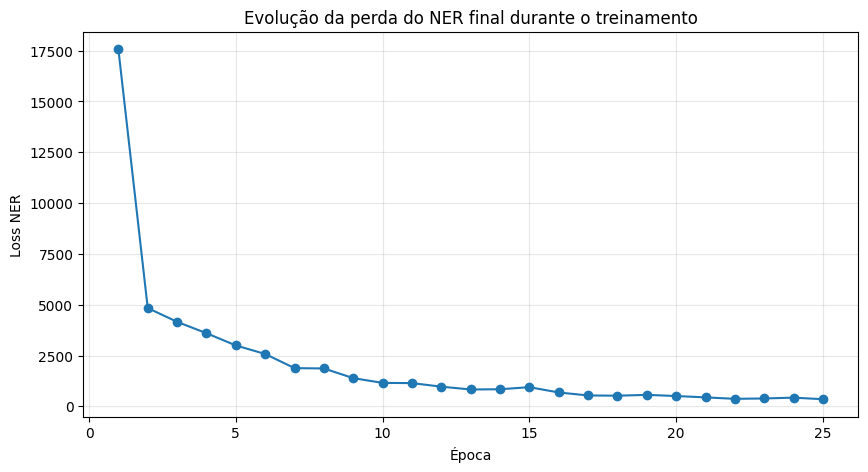

In [39]:
# ============================================================
# GRÁFICO DA PERDA DO NER FINAL
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    df_historico_treinamento_ner_final["epoch"],
    df_historico_treinamento_ner_final["loss_ner"],
    marker="o"
)

plt.title("Evolução da perda do NER final durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss NER")
plt.grid(True, alpha=0.3)

plt.show()

# 14. Avaliação do NER final

O modelo NER será avaliado no conjunto de validação.

É importante destacar que as métricas são calculadas sobre um conjunto de validação também criado de forma semiautomática.

Portanto, essas métricas indicam se o modelo aprendeu bem os padrões das labels, mas não substituem uma avaliação manual com uma base anotada por especialistas.

In [40]:
# ============================================================
# AVALIAÇÃO DO NER FINAL
# ============================================================

exemplos_validacao_final = []

for texto, anotacoes in DADOS_VALIDACAO_NER_FINAL:
    doc_predito = nlp_ner_final(texto)

    exemplo = Example.from_dict(
        doc_predito,
        anotacoes
    )

    exemplos_validacao_final.append(exemplo)

scorer_final = Scorer()

metricas_ner_final = scorer_final.score(
    exemplos_validacao_final
)

print("Métricas gerais do NER final na validação:")
print("Precisão:", round(metricas_ner_final.get("ents_p", 0), 4))
print("Revocação:", round(metricas_ner_final.get("ents_r", 0), 4))
print("F1-score:", round(metricas_ner_final.get("ents_f", 0), 4))

metricas_por_label_final = metricas_ner_final.get(
    "ents_per_type",
    {}
)

df_metricas_por_label_final = pd.DataFrame.from_dict(
    metricas_por_label_final,
    orient="index"
).reset_index()

df_metricas_por_label_final = df_metricas_por_label_final.rename(
    columns={
        "index": "label",
        "p": "precisao",
        "r": "revocacao",
        "f": "f1"
    }
)

df_metricas_por_label_final = df_metricas_por_label_final.sort_values(
    by="f1",
    ascending=False
)

display(df_metricas_por_label_final)

Métricas gerais do NER final na validação:
Precisão: 0.9391
Revocação: 0.9423
F1-score: 0.9407


,label,precisao,revocacao,f1
1,AREA_SEGURANCA_IDENTIFICACAO_AUTENTICACAO,1.000000,1.000000,1.000000
7,AREA_ALIMENTOS_AGRO,0.987179,1.000000,0.993548
13,AREA_PETROLEO_GAS_PETROQUIMICA,0.965517,1.000000,0.982456
3,AREA_ENGENHARIA_MATERIAIS,1.000000,0.962264,0.980769
15,AREA_CONSTRUCAO_CIVIL_MATERIAIS,1.000000,0.935484,0.966667
2,AREA_MINERACAO_SIDERURGIA,1.000000,0.928571,0.962963
4,AREA_QUIMICA_PROCESSOS_INDUSTRIAIS,0.948718,0.973684,0.961039
9,AREA_ENERGIA,0.954545,0.954545,0.954545
11,AREA_COMPUTACAO_DADOS,0.909091,1.000000,0.952381
0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,0.948276,0.948276,0.948276


# 15. Aplicação do NER final na base completa

Após o treinamento, aplicamos o modelo NER em todos os textos da base filtrada.

As entidades extraídas serão usadas posteriormente como parte da representação híbrida.

In [41]:
# ============================================================
# APLICAÇÃO DO NER NA BASE COMPLETA
# ============================================================

def aplicar_ner_base_completa(df_base, modelo):
    """
    Aplica o modelo NER em toda a base textual.
    """

    registros = []

    for indice, linha in tqdm(
        df_base.iterrows(),
        total=len(df_base),
        desc="Aplicando NER"
    ):
        texto = linha["texto"]

        doc = modelo(texto)

        for ent in doc.ents:
            registros.append({
                "indice_texto": indice,
                "titulo": linha["titulo"],
                "entidade": ent.text,
                "label": ent.label_,
                "inicio": ent.start_char,
                "fim": ent.end_char,
                "texto": texto
            })

    return pd.DataFrame(registros)


df_entidades_final = aplicar_ner_base_completa(
    df_base=df_textos_filtrado,
    modelo=nlp_ner_final
)

print("Quantidade total de entidades extraídas pelo NER final:")
print(len(df_entidades_final))

print("\nDistribuição de entidades extraídas por label:")
display(
    df_entidades_final["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="quantidade")
)

print("\nAmostra de entidades extraídas:")
display(df_entidades_final.head(100))

Aplicando NER:   0%|          | 0/2702 [00:00<?, ?it/s]

Quantidade total de entidades extraídas pelo NER final:
6381

Distribuição de entidades extraídas por label:


,label,quantidade
0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,878
1,AREA_SOFTWARE_PLATAFORMAS_DIGITAIS,652
2,AREA_COMPUTACAO_DADOS,595
3,AREA_ENGENHARIA_MATERIAIS,555
4,AREA_ALIMENTOS_AGRO,514
5,AREA_METROLOGIA_TESTES_QUALIDADE,440
6,AREA_QUIMICA_PROCESSOS_INDUSTRIAIS,330
7,AREA_TELECOM_FOTONICA_CONECTIVIDADE,323
8,AREA_RESIDUOS_MEIO_AMBIENTE,309
9,AREA_ENERGIA,303



Amostra de entidades extraídas:


,indice_texto,titulo,entidade,label,inicio,fim,texto
0,0,Açúcar de frutas e aplicação em bolos como sub...,alimentos,AREA_ALIMENTOS_AGRO,697,706,Açúcar de frutas e aplicação em bolos como sub...
1,1,Desenvolver uma linha de farofas com castanhas...,castanhas,AREA_ALIMENTOS_AGRO,37,46,Desenvolver uma linha de farofas com castanhas...
2,1,Desenvolver uma linha de farofas com castanhas...,linha de produção,AREA_MANUFATURA_PRODUCAO_OPERACIONAL,727,744,Desenvolver uma linha de farofas com castanhas...
3,1,Desenvolver uma linha de farofas com castanhas...,castanhas,AREA_ALIMENTOS_AGRO,770,779,Desenvolver uma linha de farofas com castanhas...
4,1,Desenvolver uma linha de farofas com castanhas...,castanhas,AREA_ALIMENTOS_AGRO,828,837,Desenvolver uma linha de farofas com castanhas...
...,...,...,...,...,...,...,...
95,22,HUAWEI - PV generation with optimal BESS based...,Armazenamento de Energia,AREA_ENERGIA,145,169,HUAWEI - PV generation with optimal BESS based...
96,22,HUAWEI - PV generation with optimal BESS based...,BESS,AREA_ENERGIA,171,175,HUAWEI - PV generation with optimal BESS based...
97,22,HUAWEI - PV generation with optimal BESS based...,Inteligência Artificial,AREA_COMPUTACAO_DADOS,241,264,HUAWEI - PV generation with optimal BESS based...
98,22,HUAWEI - PV generation with optimal BESS based...,5G.,AREA_TELECOM_FOTONICA_CONECTIVIDADE,318,321,HUAWEI - PV generation with optimal BESS based...


In [42]:
# ============================================================
# COBERTURA DO NER NA BASE
# ============================================================

qtd_entidades_por_texto_final = (
    df_entidades_final
    .groupby("indice_texto")
    .size()
    .rename("qtd_entidades_ner_final")
)

df_textos_filtrado["qtd_entidades_ner_final"] = df_textos_filtrado.index.map(
    qtd_entidades_por_texto_final
).fillna(0).astype(int)

df_textos_filtrado["possui_entidade_ner_final"] = (
    df_textos_filtrado["qtd_entidades_ner_final"] > 0
)

qtd_textos_com_ner_final = int(
    df_textos_filtrado["possui_entidade_ner_final"].sum()
)

qtd_textos_sem_ner_final = len(df_textos_filtrado) - qtd_textos_com_ner_final

df_resumo_cobertura_ner_final = pd.DataFrame([
    {
        "metrica": "Textos na base filtrada",
        "valor": len(df_textos_filtrado)
    },
    {
        "metrica": "Textos com pelo menos uma entidade NER",
        "valor": qtd_textos_com_ner_final
    },
    {
        "metrica": "Textos sem entidade NER",
        "valor": qtd_textos_sem_ner_final
    },
    {
        "metrica": "Percentual de textos com NER",
        "valor": round(
            qtd_textos_com_ner_final / len(df_textos_filtrado) * 100,
            2
        )
    },
    {
        "metrica": "Média de entidades por texto",
        "valor": round(
            df_textos_filtrado["qtd_entidades_ner_final"].mean(),
            4
        )
    }
])

display(df_resumo_cobertura_ner_final)

,metrica,valor
0,Textos na base filtrada,2702.0000
1,Textos com pelo menos uma entidade NER,2103.0000
2,Textos sem entidade NER,599.0000
3,Percentual de textos com NER,77.8300
4,Média de entidades por texto,2.3616


## 15.1 Interpretação da etapa de NER

O NER final permitiu transformar termos temáticos em variáveis estruturadas.

Essas entidades não serão usadas como uma classificação final dos textos, mas como sinais adicionais para a clusterização.

Com isso, a representação final dos textos passa a combinar:

- significado semântico geral;
- termos técnicos relevantes;
- presença de áreas temáticas reconhecidas pelo NER.

A próxima etapa será gerar embeddings com BERTimbau e montar a representação híbrida final.

# 16. Geração de embeddings com BERTimbau

Nesta etapa, usamos o modelo **BERTimbau** para gerar embeddings semânticos dos textos.

O BERTimbau é usado porque foi treinado para a língua portuguesa e consegue capturar relações semânticas que não aparecem apenas pela contagem de palavras.

Nesta versão final, os embeddings serão gerados a partir da coluna `texto_titulo_reforcado`.

Essa escolha foi feita porque o título dos projetos geralmente concentra informações importantes sobre o tema. Ao reforçar o título, damos mais peso a essa informação na representação semântica.

In [43]:
# ============================================================
# CARREGAMENTO DO BERTIMBAU
# ============================================================

tokenizer_bert = AutoTokenizer.from_pretrained(
    NOME_MODELO_BERT
)

modelo_bert = AutoModel.from_pretrained(
    NOME_MODELO_BERT
)

modelo_bert = modelo_bert.to(DEVICE)
modelo_bert.eval()

print("Modelo carregado:")
print(NOME_MODELO_BERT)

print("\nDispositivo:")
print(DEVICE)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Modelo carregado:
neuralmind/bert-base-portuguese-cased

Dispositivo:
cuda


## 16.1 Análise do tamanho dos textos em tokens

Antes de gerar os embeddings, vamos verificar o tamanho dos textos em tokens do BERTimbau.

Essa análise é importante porque modelos BERT possuem limite máximo de tokens por entrada.

Neste projeto, usamos `MAX_LEN_BERT = 256`.

Esse valor foi escolhido como equilíbrio entre:

- preservar boa parte do conteúdo dos textos;
- reduzir custo computacional;
- evitar excesso de truncamento;
- manter viável a execução no Kaggle.

In [44]:
# ============================================================
# CONTAGEM DE TOKENS BERT
# ============================================================

def contar_tokens_bert(texto, tokenizer):
    """
    Conta a quantidade de tokens gerados pelo tokenizer BERT.
    """

    tokens = tokenizer(
        str(texto),
        add_special_tokens=True,
        truncation=False,
        return_attention_mask=False
    )["input_ids"]

    return len(tokens)


df_textos_filtrado["qtd_tokens_bert"] = [
    contar_tokens_bert(texto, tokenizer_bert)
    for texto in tqdm(
        df_textos_filtrado["texto_titulo_reforcado"].tolist(),
        desc="Contando tokens BERT"
    )
]

display(
    df_textos_filtrado["qtd_tokens_bert"]
    .describe()
    .to_frame()
    .T
)

df_limites_tokens = pd.DataFrame([
    {
        "limite_tokens": 128,
        "quantidade_textos_acima": int((df_textos_filtrado["qtd_tokens_bert"] > 128).sum()),
        "percentual_textos_acima": round((df_textos_filtrado["qtd_tokens_bert"] > 128).mean() * 100, 2)
    },
    {
        "limite_tokens": 256,
        "quantidade_textos_acima": int((df_textos_filtrado["qtd_tokens_bert"] > 256).sum()),
        "percentual_textos_acima": round((df_textos_filtrado["qtd_tokens_bert"] > 256).mean() * 100, 2)
    },
    {
        "limite_tokens": 384,
        "quantidade_textos_acima": int((df_textos_filtrado["qtd_tokens_bert"] > 384).sum()),
        "percentual_textos_acima": round((df_textos_filtrado["qtd_tokens_bert"] > 384).mean() * 100, 2)
    },
    {
        "limite_tokens": 512,
        "quantidade_textos_acima": int((df_textos_filtrado["qtd_tokens_bert"] > 512).sum()),
        "percentual_textos_acima": round((df_textos_filtrado["qtd_tokens_bert"] > 512).mean() * 100, 2)
    }
])

display(df_limites_tokens)

Contando tokens BERT:   0%|          | 0/2702 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
qtd_tokens_bert,2702.0,109.837898,92.150945,13.0,50.0,81.0,135.0,787.0


,limite_tokens,quantidade_textos_acima,percentual_textos_acima
0,128,732,27.09
1,256,191,7.07
2,384,55,2.04
3,512,22,0.81


In [45]:
# ============================================================
# FUNÇÕES PARA GERAÇÃO DE EMBEDDINGS BERT
# ============================================================

def mean_pooling_bert(last_hidden_state, attention_mask):
    """
    Aplica mean pooling nos embeddings de tokens do BERT,
    considerando apenas tokens válidos pela attention_mask.
    """

    token_embeddings = last_hidden_state

    mascara_expandida = (
        attention_mask
        .unsqueeze(-1)
        .expand(token_embeddings.size())
        .float()
    )

    soma_embeddings = torch.sum(
        token_embeddings * mascara_expandida,
        dim=1
    )

    soma_mascara = torch.clamp(
        mascara_expandida.sum(dim=1),
        min=1e-9
    )

    embeddings_medios = soma_embeddings / soma_mascara

    return embeddings_medios


def gerar_embeddings_bert(
    textos,
    tokenizer,
    modelo,
    max_len=256,
    batch_size=16,
    device="cpu"
):
    """
    Gera embeddings BERT para uma lista de textos usando mean pooling.
    """

    todos_embeddings = []

    modelo.eval()

    for inicio in tqdm(
        range(0, len(textos), batch_size),
        desc="Gerando embeddings BERT"
    ):
        fim = inicio + batch_size
        batch_textos = textos[inicio:fim]

        entradas = tokenizer(
            batch_textos,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        entradas = {
            chave: valor.to(device)
            for chave, valor in entradas.items()
        }

        with torch.no_grad():
            saida = modelo(**entradas)

        embeddings_batch = mean_pooling_bert(
            last_hidden_state=saida.last_hidden_state,
            attention_mask=entradas["attention_mask"]
        )

        todos_embeddings.append(
            embeddings_batch.detach().cpu().numpy()
        )

    embeddings = np.vstack(todos_embeddings)

    return embeddings

In [46]:
# ============================================================
# GERAÇÃO DOS EMBEDDINGS BERT FINAIS
# ============================================================

textos_para_bert = df_textos_filtrado["texto_titulo_reforcado"].tolist()

embeddings_bert_final = gerar_embeddings_bert(
    textos=textos_para_bert,
    tokenizer=tokenizer_bert,
    modelo=modelo_bert,
    max_len=MAX_LEN_BERT,
    batch_size=BATCH_SIZE_BERT,
    device=DEVICE
)

print("Formato dos embeddings BERT:")
print(embeddings_bert_final.shape)

print("\nHá valores NaN?")
print(np.isnan(embeddings_bert_final).any())

print("\nHá valores infinitos?")
print(np.isinf(embeddings_bert_final).any())

Gerando embeddings BERT:   0%|          | 0/169 [00:00<?, ?it/s]

Formato dos embeddings BERT:
(2702, 768)

Há valores NaN?
False

Há valores infinitos?
False


## 16.2 Redução dimensional dos embeddings BERT

Os embeddings do BERTimbau possuem 768 dimensões.

Para combinar esses embeddings com TF-IDF/SVD e NER, reduzimos a dimensionalidade com PCA.

Nesta etapa, usamos 50 componentes principais.

Isso reduz ruído, diminui custo computacional e mantém uma representação semântica compacta dos textos.

In [47]:
# ============================================================
# PCA DOS EMBEDDINGS BERT
# ============================================================

embeddings_bert_final_norm = normalize(
    embeddings_bert_final,
    norm="l2"
)

pca_bert_final = PCA(
    n_components=50,
    random_state=RANDOM_STATE
)

features_bert_final = pca_bert_final.fit_transform(
    embeddings_bert_final_norm
)

print("Formato das features BERT após PCA:")
print(features_bert_final.shape)

print("\nVariância explicada pelo PCA BERT:")
print(pca_bert_final.explained_variance_ratio_.sum())

Formato das features BERT após PCA:
(2702, 50)

Variância explicada pelo PCA BERT:
0.7007304


# 17. Representação TF-IDF/SVD

Além da representação semântica do BERTimbau, também usamos TF-IDF.

O TF-IDF ajuda a preservar termos técnicos específicos que podem ser muito importantes para diferenciar áreas.

Em seguida, aplicamos SVD para reduzir a dimensionalidade da matriz TF-IDF.

In [48]:
# ============================================================
# TF-IDF FINAL
# ============================================================

vectorizer_tfidf_final = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85
)

matriz_tfidf_final = vectorizer_tfidf_final.fit_transform(
    df_textos_filtrado["texto"].tolist()
)

termos_tfidf_final = np.array(
    vectorizer_tfidf_final.get_feature_names_out()
)

print("Formato da matriz TF-IDF final:")
print(matriz_tfidf_final.shape)

Formato da matriz TF-IDF final:
(2702, 6898)


In [49]:
# ============================================================
# SVD DA MATRIZ TF-IDF
# ============================================================

svd_tfidf_final = TruncatedSVD(
    n_components=50,
    random_state=RANDOM_STATE
)

features_tfidf_final = svd_tfidf_final.fit_transform(
    matriz_tfidf_final
)

print("Formato das features TF-IDF/SVD:")
print(features_tfidf_final.shape)

print("\nVariância explicada pelo SVD:")
print(svd_tfidf_final.explained_variance_ratio_.sum())

Formato das features TF-IDF/SVD:
(2702, 50)

Variância explicada pelo SVD:
0.12352953364001487


# 18. Construção das features do NER

O terceiro componente da representação híbrida vem das entidades extraídas pelo NER final.

Para cada texto, serão criadas duas informações por label:

1. proporção de entidades daquela label no texto;
2. indicador binário informando se a label apareceu ou não no texto.

Assim, o NER passa a funcionar como um conjunto de sinais temáticos estruturados.

In [50]:
# ============================================================
# FEATURES DO NER FINAL
# ============================================================

labels_ner_final_ordenadas = sorted(
    labels_ner_treino_final.keys()
)

df_ner_counts_final = (
    df_entidades_final
    .groupby(["indice_texto", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=df_textos_filtrado.index,
        columns=labels_ner_final_ordenadas,
        fill_value=0
    )
)

soma_entidades_por_texto_final = df_ner_counts_final.sum(axis=1).replace(0, 1)

df_ner_prop_final = df_ner_counts_final.div(
    soma_entidades_por_texto_final,
    axis=0
)

df_ner_bin_final = (
    df_ner_counts_final > 0
).astype(int)

features_ner_final = np.hstack([
    df_ner_prop_final.values,
    df_ner_bin_final.values
])

print("Features NER final:")
print(features_ner_final.shape)

print("\nLabels NER usadas nas features:")
print(labels_ner_final_ordenadas)

print("\nAmostra da matriz de contagem de entidades:")
display(df_ner_counts_final.head())


Features NER final:
(2702, 38)

Labels NER usadas nas features:
['AREA_ALIMENTOS_AGRO', 'AREA_AUTOMOTIVA_MOBILIDADE', 'AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO', 'AREA_COMPUTACAO_DADOS', 'AREA_CONSTRUCAO_CIVIL_MATERIAIS', 'AREA_ENERGIA', 'AREA_ENGENHARIA_MATERIAIS', 'AREA_GESTAO_LOGISTICA_NEGOCIOS', 'AREA_MANUFATURA_PRODUCAO_OPERACIONAL', 'AREA_METROLOGIA_TESTES_QUALIDADE', 'AREA_MINERACAO_SIDERURGIA', 'AREA_PETROLEO_GAS_PETROQUIMICA', 'AREA_QUIMICA_PROCESSOS_INDUSTRIAIS', 'AREA_RESIDUOS_MEIO_AMBIENTE', 'AREA_SAUDE_BIOTECNOLOGIA', 'AREA_SEGURANCA_IDENTIFICACAO_AUTENTICACAO', 'AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO', 'AREA_SOFTWARE_PLATAFORMAS_DIGITAIS', 'AREA_TELECOM_FOTONICA_CONECTIVIDADE']

Amostra da matriz de contagem de entidades:


label,AREA_ALIMENTOS_AGRO,AREA_AUTOMOTIVA_MOBILIDADE,AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO,AREA_COMPUTACAO_DADOS,AREA_CONSTRUCAO_CIVIL_MATERIAIS,AREA_ENERGIA,AREA_ENGENHARIA_MATERIAIS,AREA_GESTAO_LOGISTICA_NEGOCIOS,AREA_MANUFATURA_PRODUCAO_OPERACIONAL,AREA_METROLOGIA_TESTES_QUALIDADE,AREA_MINERACAO_SIDERURGIA,AREA_PETROLEO_GAS_PETROQUIMICA,AREA_QUIMICA_PROCESSOS_INDUSTRIAIS,AREA_RESIDUOS_MEIO_AMBIENTE,AREA_SAUDE_BIOTECNOLOGIA,AREA_SEGURANCA_IDENTIFICACAO_AUTENTICACAO,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,AREA_SOFTWARE_PLATAFORMAS_DIGITAIS,AREA_TELECOM_FOTONICA_CONECTIVIDADE
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [51]:
# ============================================================
# VALIDAÇÃO DA REPRESENTAÇÃO FINAL
# ============================================================

assert len(labels_ner_treino_final) == 19, (
    f"Erro: a V3.1 final deve ter 19 labels, mas foram encontradas {len(labels_ner_treino_final)}."
)

assert features_ner_final.shape[1] == 38, (
    f"Erro: as features NER devem ter 38 colunas, mas têm {features_ner_final.shape[1]}."
)

print("Validação da representação final concluída.")
print("Quantidade de labels:", len(labels_ner_treino_final))
print("Formato das features NER:", features_ner_final.shape)


Validação da representação final concluída.
Quantidade de labels: 19
Formato das features NER: (2702, 38)


# 19. Representação híbrida final

A representação final combina três fontes de informação:

1. **BERTimbau/PCA**, para significado semântico;
2. **TF-IDF/SVD**, para termos técnicos;
3. **NER**, para sinais temáticos estruturados.

Antes da combinação, cada grupo de features é padronizado com `StandardScaler`.

Depois, aplicamos os pesos definidos experimentalmente:

- BERT: 1.0;
- TF-IDF: 0.8;
- NER: 1.3.

Por fim, a matriz final é normalizada com norma L2.

In [52]:
# ============================================================
# REPRESENTAÇÃO HÍBRIDA FINAL
# ============================================================

scaler_bert_final = StandardScaler()
scaler_tfidf_final = StandardScaler()
scaler_ner_final = StandardScaler()

features_bert_final_scaled = scaler_bert_final.fit_transform(
    features_bert_final
)

features_tfidf_final_scaled = scaler_tfidf_final.fit_transform(
    features_tfidf_final
)

features_ner_final_scaled = scaler_ner_final.fit_transform(
    features_ner_final
)

features_hibridas_final = np.hstack([
    features_bert_final_scaled * PESO_BERT_FINAL,
    features_tfidf_final_scaled * PESO_TFIDF_FINAL,
    features_ner_final_scaled * PESO_NER_FINAL
])

features_hibridas_final_norm = normalize(
    features_hibridas_final,
    norm="l2"
)

print("Formato final das features híbridas:")
print(features_hibridas_final_norm.shape)

print("\nPesos usados:")
print("PESO_BERT_FINAL:", PESO_BERT_FINAL)
print("PESO_TFIDF_FINAL:", PESO_TFIDF_FINAL)
print("PESO_NER_FINAL:", PESO_NER_FINAL)

print("\nHá valores NaN?")
print(np.isnan(features_hibridas_final_norm).any())

print("\nHá valores infinitos?")
print(np.isinf(features_hibridas_final_norm).any())

Formato final das features híbridas:
(2702, 138)

Pesos usados:
PESO_BERT_FINAL: 1.0
PESO_TFIDF_FINAL: 0.8
PESO_NER_FINAL: 1.3

Há valores NaN?
False

Há valores infinitos?
False


# 20. Avaliação do número de clusters

Nesta etapa, testamos diferentes valores de `k` para o KMeans.

A métrica principal utilizada é o **Silhouette Score**.

Também analisamos o tamanho do menor e do maior cluster, pois um bom resultado não deve depender apenas da métrica numérica. A interpretabilidade dos agrupamentos também é fundamental.

In [53]:
# ============================================================
# AVALIAÇÃO DO KMEANS COM DIFERENTES VALORES DE K
# ============================================================

valores_k_final = list(range(2, 21))

resultados_kmeans_final = []

for k in valores_k_final:
    print(f"Treinando KMeans final com k={k}...")

    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels_temp = kmeans_temp.fit_predict(
        features_hibridas_final_norm
    )

    silhouette_temp = silhouette_score(
        features_hibridas_final_norm,
        labels_temp,
        metric="euclidean"
    )

    contagem_clusters = pd.Series(labels_temp).value_counts()

    resultados_kmeans_final.append({
        "representacao": "hibrida_final_bert_tfidf_ner",
        "k": k,
        "silhouette_score": silhouette_temp,
        "inertia": kmeans_temp.inertia_,
        "menor_cluster": int(contagem_clusters.min()),
        "maior_cluster": int(contagem_clusters.max()),
        "percentual_menor_cluster": round(contagem_clusters.min() / len(labels_temp) * 100, 2),
        "percentual_maior_cluster": round(contagem_clusters.max() / len(labels_temp) * 100, 2)
    })

df_resultados_kmeans_final = pd.DataFrame(
    resultados_kmeans_final
)

display(df_resultados_kmeans_final)

Treinando KMeans final com k=2...
Treinando KMeans final com k=3...
Treinando KMeans final com k=4...
Treinando KMeans final com k=5...
Treinando KMeans final com k=6...
Treinando KMeans final com k=7...
Treinando KMeans final com k=8...
Treinando KMeans final com k=9...
Treinando KMeans final com k=10...
Treinando KMeans final com k=11...
Treinando KMeans final com k=12...
Treinando KMeans final com k=13...
Treinando KMeans final com k=14...
Treinando KMeans final com k=15...
Treinando KMeans final com k=16...
Treinando KMeans final com k=17...
Treinando KMeans final com k=18...
Treinando KMeans final com k=19...
Treinando KMeans final com k=20...


,representacao,k,silhouette_score,inertia,menor_cluster,maior_cluster,percentual_menor_cluster,percentual_maior_cluster
0,hibrida_final_bert_tfidf_ner,2,0.033797,2611.309714,955,1747,35.34,64.66
1,hibrida_final_bert_tfidf_ner,3,0.040623,2538.803380,343,1727,12.69,63.92
2,hibrida_final_bert_tfidf_ner,4,0.047299,2470.449654,218,1528,8.07,56.55
3,hibrida_final_bert_tfidf_ner,5,0.054591,2409.322800,216,1310,7.99,48.48
4,hibrida_final_bert_tfidf_ner,6,0.062717,2355.536305,142,1394,5.26,51.59
5,hibrida_final_bert_tfidf_ner,7,0.064998,2315.350950,141,941,5.22,34.83
6,hibrida_final_bert_tfidf_ner,8,0.074824,2259.402979,138,951,5.11,35.20
7,hibrida_final_bert_tfidf_ner,9,0.078944,2214.027355,138,929,5.11,34.38
8,hibrida_final_bert_tfidf_ner,10,0.085669,2165.569330,133,913,4.92,33.79
9,hibrida_final_bert_tfidf_ner,11,0.087167,2125.661714,130,846,4.81,31.31


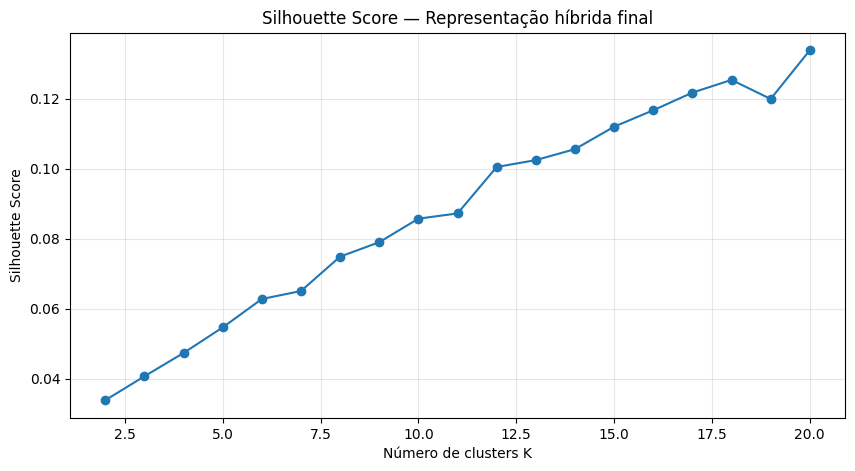

In [54]:
# ============================================================
# GRÁFICO DO SILHOUETTE SCORE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    df_resultados_kmeans_final["k"],
    df_resultados_kmeans_final["silhouette_score"],
    marker="o"
)

plt.title("Silhouette Score — Representação híbrida final")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)

plt.show()

In [55]:
# ============================================================
# CANDIDATOS INTERPRETÁVEIS
# ============================================================

df_candidatos_kmeans_final = df_resultados_kmeans_final[
    (df_resultados_kmeans_final["k"] >= 8)
    & (df_resultados_kmeans_final["percentual_menor_cluster"] >= 1.0)
].sort_values(
    by="silhouette_score",
    ascending=False
)

print("Candidatos interpretáveis:")
display(df_candidatos_kmeans_final)

Candidatos interpretáveis:


,representacao,k,silhouette_score,inertia,menor_cluster,maior_cluster,percentual_menor_cluster,percentual_maior_cluster
18,hibrida_final_bert_tfidf_ner,20,0.133795,1823.856248,35,599,1.30,22.17
16,hibrida_final_bert_tfidf_ner,18,0.125319,1870.699268,70,626,2.59,23.17
15,hibrida_final_bert_tfidf_ner,17,0.121679,1899.448420,70,647,2.59,23.95
17,hibrida_final_bert_tfidf_ner,19,0.119866,1858.431895,70,626,2.59,23.17
14,hibrida_final_bert_tfidf_ner,16,0.116639,1934.492902,72,663,2.66,24.54
13,hibrida_final_bert_tfidf_ner,15,0.111942,1965.359212,74,690,2.74,25.54
12,hibrida_final_bert_tfidf_ner,14,0.105530,2005.144357,102,706,3.77,26.13
11,hibrida_final_bert_tfidf_ner,13,0.102402,2045.214017,75,720,2.78,26.65
10,hibrida_final_bert_tfidf_ner,12,0.100433,2081.774756,76,791,2.81,29.27
9,hibrida_final_bert_tfidf_ner,11,0.087167,2125.661714,130,846,4.81,31.31


## 20.1 Escolha do K final

A versão final do projeto utiliza `k = 20`.

Essa escolha foi feita porque, nos testes da V3.1, esse valor apresentou o melhor equilíbrio entre:

- maior Silhouette Score;
- redução do cluster residual;
- criação de grupos temáticos interpretáveis;
- separação de áreas específicas que antes ficavam misturadas.

Mesmo sendo uma escolha mais granular, `k = 20` permitiu identificar temas como software, telecomunicações, metrologia, mineração, bioprocessos, construção civil, petróleo e gestão/logística.

In [56]:
# ============================================================
# DEFINIÇÃO DO K FINAL
# ============================================================

K_FINAL_ESCOLHIDO = K_FINAL

melhor_linha_k_final = df_resultados_kmeans_final[
    df_resultados_kmeans_final["k"] == K_FINAL_ESCOLHIDO
].iloc[0]

print("K final escolhido:")
print(K_FINAL_ESCOLHIDO)

print("\nSilhouette Score correspondente:")
print(melhor_linha_k_final["silhouette_score"])

K final escolhido:
20

Silhouette Score correspondente:
0.13379478024078298


In [57]:
# ============================================================
# TREINAMENTO DO KMEANS FINAL
# ============================================================

kmeans_final = KMeans(
    n_clusters=K_FINAL_ESCOLHIDO,
    random_state=RANDOM_STATE,
    n_init=80
)

clusters_finais = kmeans_final.fit_predict(
    features_hibridas_final_norm
)

df_textos_filtrado["cluster_final"] = clusters_finais

print("Distribuição de textos por cluster final:")
display(
    df_textos_filtrado["cluster_final"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_final")
    .reset_index(name="quantidade_textos")
)

Distribuição de textos por cluster final:


,cluster_final,quantidade_textos
0,0,110
1,1,166
2,2,87
3,3,68
4,4,599
5,5,124
6,6,72
7,7,211
8,8,133
9,9,90


# 21. Visualização inicial dos clusters

Para visualizar os agrupamentos, usamos PCA e t-SNE.

O PCA ajuda a observar uma projeção linear dos dados.

O t-SNE ajuda a visualizar agrupamentos locais em duas dimensões.

Essas visualizações não substituem as métricas nem a análise textual dos clusters, mas ajudam a interpretar a organização geral dos grupos.

Variância explicada pelos dois componentes PCA:
[0.04171041 0.03356596]

Variância explicada acumulada:
0.07527636897624101


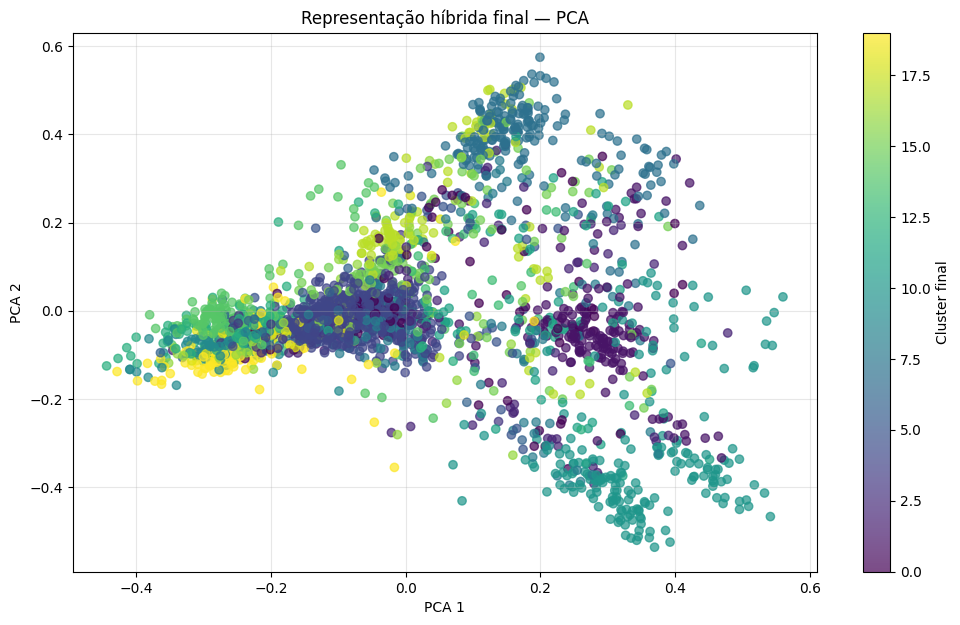

In [58]:
# ============================================================
# PCA 2D PARA VISUALIZAÇÃO
# ============================================================

pca_visual_final = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

features_hibridas_final_pca2 = pca_visual_final.fit_transform(
    features_hibridas_final_norm
)

df_textos_filtrado["pca_final_1"] = features_hibridas_final_pca2[:, 0]
df_textos_filtrado["pca_final_2"] = features_hibridas_final_pca2[:, 1]

print("Variância explicada pelos dois componentes PCA:")
print(pca_visual_final.explained_variance_ratio_)

print("\nVariância explicada acumulada:")
print(pca_visual_final.explained_variance_ratio_.sum())

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_textos_filtrado["pca_final_1"],
    df_textos_filtrado["pca_final_2"],
    c=df_textos_filtrado["cluster_final"],
    alpha=0.7
)

plt.title("Representação híbrida final — PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster final")

plt.show()

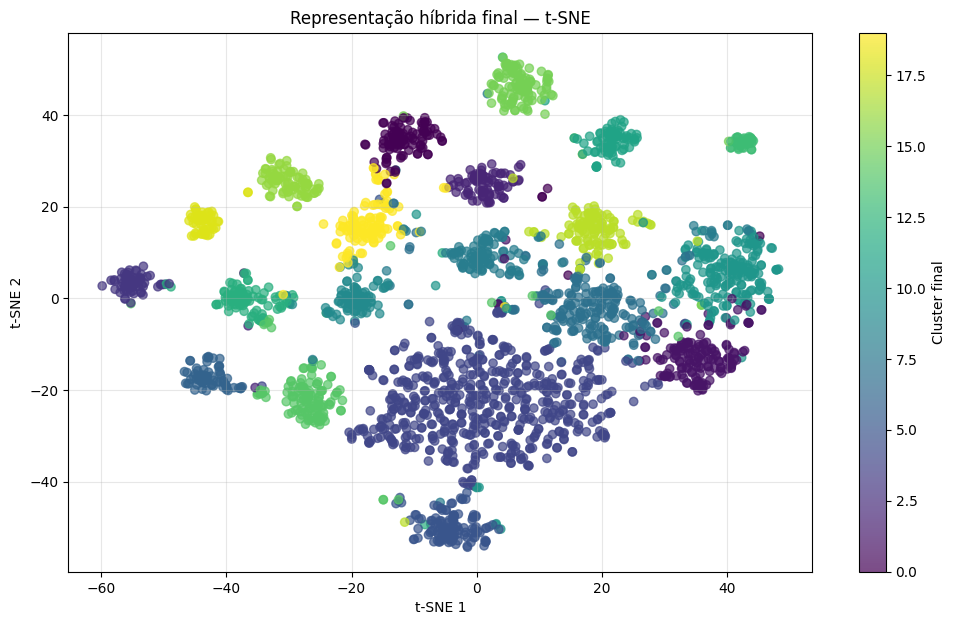

In [59]:
# ============================================================
# t-SNE 2D PARA VISUALIZAÇÃO
# ============================================================

tsne_final = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

features_hibridas_final_tsne = tsne_final.fit_transform(
    features_hibridas_final_norm
)

df_textos_filtrado["tsne_final_1"] = features_hibridas_final_tsne[:, 0]
df_textos_filtrado["tsne_final_2"] = features_hibridas_final_tsne[:, 1]

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_textos_filtrado["tsne_final_1"],
    df_textos_filtrado["tsne_final_2"],
    c=df_textos_filtrado["cluster_final"],
    alpha=0.7
)

plt.title("Representação híbrida final — t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster final")

plt.show()

# 22. Resultado da clusterização

Ao final desta etapa, cada texto recebeu um cluster final na coluna `cluster_final`.

Na próxima seção, os clusters serão interpretados a partir de:

- termos TF-IDF principais;
- entidades NER dominantes;
- títulos representativos próximos aos centroides;
- cobertura do NER por cluster;
- nomeação manual dos grupos.

# 23. Interpretação dos clusters finais

Após a clusterização com KMeans, cada texto recebeu um número de cluster.

Esses números não possuem significado semântico por si mesmos. Por exemplo, o algoritmo sabe apenas que existem os clusters `0`, `1`, `2`, etc.

Para interpretar os grupos, vamos analisar:

- os termos TF-IDF mais importantes em cada cluster;
- as entidades NER mais frequentes em cada cluster;
- os títulos mais próximos dos centroides;
- a cobertura do NER em cada cluster.

Com base nesses elementos, os clusters serão nomeados manualmente.

In [60]:
# ============================================================
# TÍTULOS REPRESENTATIVOS POR CLUSTER
# ============================================================

df_titulos_representativos_final = obter_titulos_proximos_centroides(
    df_base=df_textos_filtrado,
    embeddings_cluster=features_hibridas_final_norm,
    kmeans=kmeans_final,
    coluna_cluster="cluster_final",
    n=12
)

display(df_titulos_representativos_final)

,cluster,posicao,titulo,qtd_palavras,distancia_centroide
0,0,1,TRANSIÇÃO ENERGÉTICA NO TRANSPORTE RODOVIÁRIO,47,0.546210
1,0,2,Algoritmo Quântico para otimização de distribu...,62,0.559086
2,0,3,VAL - Veículo Autônomo Lynx,76,0.560421
3,0,4,Geração de datasets sintéticos com transferênc...,58,0.565294
4,0,5,IA para auxílio no dimensionamento do valor de...,51,0.573935
...,...,...,...,...,...
235,19,8,Desenvolvimento de estratégias para impressão ...,160,0.636572
236,19,9,Avaliação de Potenciais Insumos no aço SAE1010...,40,0.639126
237,19,10,Desenvolvimento de componentes resistentes à c...,142,0.639490
238,19,11,DRS: DEMO - Demonstrador Técnico Econômico de ...,155,0.643372


In [61]:
# ============================================================
# TERMOS TF-IDF PRINCIPAIS POR CLUSTER
# ============================================================

df_tfidf_clusters_final = calcular_tfidf_medio_por_cluster(
    df_base=df_textos_filtrado,
    coluna_texto="texto",
    coluna_cluster="cluster_final",
    top_n=25
)

display(df_tfidf_clusters_final)

,cluster,posicao,termo,peso_tfidf_medio
0,0,1,veiculos,0.065112
1,0,2,veiculo,0.040939
2,0,3,sistema,0.034797
3,0,4,dados,0.032111
4,0,5,eletricos,0.030956
...,...,...,...,...
495,19,21,otimizacao,0.018933
496,19,22,sistema,0.018726
497,19,23,termico,0.018636
498,19,24,reducao,0.018408


In [62]:
# ============================================================
# ENTIDADES NER POR CLUSTER
# ============================================================

df_entidades_com_cluster_final = df_entidades_final.merge(
    df_textos_filtrado[["cluster_final"]],
    left_on="indice_texto",
    right_index=True,
    how="left"
)

print("Quantidade de entidades com cluster associado:")
print(len(df_entidades_com_cluster_final))

print("\nQuantidade de entidades sem cluster associado:")
print(df_entidades_com_cluster_final["cluster_final"].isna().sum())

df_entidades_por_cluster_final = (
    df_entidades_com_cluster_final
    .groupby(["cluster_final", "label"])
    .size()
    .reset_index(name="quantidade_entidades")
    .sort_values(
        ["cluster_final", "quantidade_entidades"],
        ascending=[True, False]
    )
)

display(df_entidades_por_cluster_final)

Quantidade de entidades com cluster associado:
6381

Quantidade de entidades sem cluster associado:
0


,cluster_final,label,quantidade_entidades
1,0,AREA_AUTOMOTIVA_MOBILIDADE,240
11,0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,59
2,0,AREA_COMPUTACAO_DADOS,34
12,0,AREA_SOFTWARE_PLATAFORMAS_DIGITAIS,25
6,0,AREA_METROLOGIA_TESTES_QUALIDADE,17
...,...,...,...
229,19,AREA_ALIMENTOS_AGRO,2
234,19,AREA_MANUFATURA_PRODUCAO_OPERACIONAL,2
239,19,AREA_SAUDE_BIOTECNOLOGIA,2
233,19,AREA_GESTAO_LOGISTICA_NEGOCIOS,1


In [63]:
# ============================================================
# COBERTURA DO NER POR CLUSTER
# ============================================================

df_cobertura_ner_clusters_final = (
    df_textos_filtrado
    .groupby("cluster_final")
    .agg(
        quantidade_textos=("texto", "count"),
        textos_com_entidade_ner=("possui_entidade_ner_final", "sum"),
        media_entidades_por_texto=("qtd_entidades_ner_final", "mean")
    )
    .reset_index()
)

df_cobertura_ner_clusters_final["textos_sem_entidade_ner"] = (
    df_cobertura_ner_clusters_final["quantidade_textos"]
    - df_cobertura_ner_clusters_final["textos_com_entidade_ner"]
)

df_cobertura_ner_clusters_final["percentual_com_entidade_ner"] = (
    df_cobertura_ner_clusters_final["textos_com_entidade_ner"]
    / df_cobertura_ner_clusters_final["quantidade_textos"]
    * 100
).round(2)

df_cobertura_ner_clusters_final["percentual_sem_entidade_ner"] = (
    df_cobertura_ner_clusters_final["textos_sem_entidade_ner"]
    / df_cobertura_ner_clusters_final["quantidade_textos"]
    * 100
).round(2)

display(df_cobertura_ner_clusters_final)

,cluster_final,quantidade_textos,textos_com_entidade_ner,media_entidades_por_texto,textos_sem_entidade_ner,percentual_com_entidade_ner,percentual_sem_entidade_ner
0,0,110,110,3.800000,0,100.0,0.0
1,1,166,166,1.837349,0,100.0,0.0
2,2,87,87,3.310345,0,100.0,0.0
3,3,68,68,3.235294,0,100.0,0.0
4,4,599,0,0.000000,599,0.0,100.0
5,5,124,124,2.741935,0,100.0,0.0
6,6,72,72,3.388889,0,100.0,0.0
7,7,211,211,2.251185,0,100.0,0.0
8,8,133,133,2.466165,0,100.0,0.0
9,9,90,90,2.422222,0,100.0,0.0


In [64]:
# ============================================================
# RESUMO AUTOMÁTICO DOS CLUSTERS
# ============================================================

resumo_clusters_final = []

for cluster_id in sorted(df_textos_filtrado["cluster_final"].unique()):
    df_cluster = df_textos_filtrado[
        df_textos_filtrado["cluster_final"] == cluster_id
    ]

    termos_principais = (
        df_tfidf_clusters_final[
            df_tfidf_clusters_final["cluster"] == cluster_id
        ]
        .head(10)["termo"]
        .tolist()
    )

    labels_principais = (
        df_entidades_por_cluster_final[
            df_entidades_por_cluster_final["cluster_final"] == cluster_id
        ]
        .head(5)
        .apply(
            lambda linha: f"{linha['label']} ({linha['quantidade_entidades']})",
            axis=1
        )
        .tolist()
    )

    titulos_representativos = (
        df_titulos_representativos_final[
            df_titulos_representativos_final["cluster"] == cluster_id
        ]
        .head(5)["titulo"]
        .tolist()
    )

    resumo_clusters_final.append({
        "cluster": int(cluster_id),
        "quantidade_textos": len(df_cluster),
        "termos_principais": ", ".join(termos_principais),
        "labels_ner_principais": ", ".join(labels_principais),
        "titulos_representativos": " | ".join(titulos_representativos)
    })

df_resumo_clusters_final = pd.DataFrame(
    resumo_clusters_final
)

display(df_resumo_clusters_final)

,cluster,quantidade_textos,termos_principais,labels_ner_principais,titulos_representativos
0,0,110,"veiculos, veiculo, sistema, dados, eletricos, ...","AREA_AUTOMOTIVA_MOBILIDADE (240), AREA_SISTEMA...",TRANSIÇÃO ENERGÉTICA NO TRANSPORTE RODOVIÁRIO ...
1,1,166,"software, plataforma, embarcado, plataforma so...","AREA_SOFTWARE_PLATAFORMAS_DIGITAIS (256), AREA...",Desenvolvimento de soluções de software embarc...
2,2,87,"producao, sistema, produtivo, industria, manuf...","AREA_MANUFATURA_PRODUCAO_OPERACIONAL (109), AR...",Planejamento inteligente da linha de produção ...
3,3,68,"minerio, ferro, zinco, rota, minerio ferro, be...","AREA_MINERACAO_SIDERURGIA (155), AREA_ENGENHAR...",Diminuição da rejeição de pirocloro para a bar...
4,4,599,"sistema, producao, sistemas, prototipo, contro...",,"Local Prints | Desenvolvimento de um atuador, ..."
5,5,124,"pacientes, sistema, tratamento, saude, pacient...","AREA_SAUDE_BIOTECNOLOGIA (234), AREA_SOFTWARE_...",Desenvolvimento de Implante Hormonal | ESTUDOS...
6,6,72,"producao, enzimas, fermentacao, controle, biom...","AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO (111),...",Destoca biológica | Desenvolvimento de disposi...
7,7,211,"sistema, iot, monitoramento, hardware, sensor,...","AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (380), A...",FIRMWARE VIA ETHERNET | Sistema de monitoramen...
8,8,133,"validacao, sistema, inspecao, conceito, medica...","AREA_METROLOGIA_TESTES_QUALIDADE (213), AREA_S...",Plataformas para Ativação e Validação de Detec...
9,9,90,"revestimento, resina, revestimentos, polimeric...","AREA_QUIMICA_PROCESSOS_INDUSTRIAIS (174), AREA...",Síntese de novos polímeros de policondensação ...


# 24. Nomeação manual dos clusters

A nomeação dos clusters foi feita manualmente com base na análise conjunta de:

- termos TF-IDF;
- entidades NER;
- títulos representativos;
- cobertura do NER;
- visualização t-SNE.

É importante destacar que o KMeans não gera nomes de clusters. Ele gera apenas agrupamentos numéricos.

Os nomes abaixo são uma interpretação humana dos padrões encontrados.

In [65]:
# ============================================================
# NOMEAÇÃO DOS CLUSTERS FINAIS
# ============================================================

nomes_clusters_finais = {
    0: "Energia, baterias e sistemas elétricos",
    1: "IA, ciência de dados e visão computacional",
    2: "Automotiva, mobilidade e veículos elétricos",
    3: "Projetos técnico-operacionais gerais e rotas tecnológicas",
    4: "Resíduos, meio ambiente e reaproveitamento",
    5: "Gestão, logística e negócios digitais",
    6: "Telecomunicações, conectividade e fotônica",
    7: "Química, polímeros, revestimentos e formulações",
    8: "Agro, alimentos e fertilizantes",
    9: "Segurança, identificação e autenticação",
    10: "Metrologia, testes, validação e qualidade",
    11: "Software, plataformas e serviços digitais",
    12: "Petróleo, gás e petroquímica",
    13: "Engenharia de materiais, manufatura e metalurgia",
    14: "Mineração, siderurgia e beneficiamento mineral",
    15: "Manufatura, produção operacional e indústria 4.0",
    16: "Sistemas, IoT, sensores e automação",
    17: "Construção civil e materiais de construção",
    18: "Saúde, biotecnologia e aplicações biomédicas",
    19: "Bioprocessos, bioativos e fermentação"
}

nomes_clusters_finais_curto = {
    0: "Energia",
    1: "IA/Dados",
    2: "Automotiva",
    3: "Residual técnico",
    4: "Resíduos",
    5: "Gestão/Logística",
    6: "Telecom/Fotônica",
    7: "Química",
    8: "Agro",
    9: "Segurança",
    10: "Testes/Qualidade",
    11: "Software",
    12: "Petróleo/Gás",
    13: "Materiais",
    14: "Mineração",
    15: "Manufatura",
    16: "Sistemas/IoT",
    17: "Construção civil",
    18: "Saúde",
    19: "Bioprocessos"
}


# O número do cluster residual pode mudar entre execuções.
# Por isso, antes de criar as colunas de nomes, detectamos o cluster
# com maior percentual de textos sem entidade NER e sobrescrevemos seu nome.
cluster_residual_preliminar = int(
    df_cobertura_ner_clusters_final
    .sort_values(
        by=[
            "percentual_sem_entidade_ner",
            "quantidade_textos"
        ],
        ascending=[False, False]
    )
    .iloc[0]["cluster_final"]
)

nomes_clusters_finais[cluster_residual_preliminar] = (
    "Projetos técnico-operacionais gerais e rotas tecnológicas"
)

nomes_clusters_finais_curto[cluster_residual_preliminar] = (
    "Residual técnico"
)

print("Cluster residual detectado para nomeação:")
print(cluster_residual_preliminar)

df_textos_filtrado["nome_cluster_final"] = (
    df_textos_filtrado["cluster_final"]
    .map(nomes_clusters_finais)
)

df_textos_filtrado["nome_cluster_final_curto"] = (
    df_textos_filtrado["cluster_final"]
    .map(nomes_clusters_finais_curto)
)

df_resumo_clusters_final_nomeado = df_resumo_clusters_final.copy()

df_resumo_clusters_final_nomeado["nome_cluster"] = (
    df_resumo_clusters_final_nomeado["cluster"]
    .map(nomes_clusters_finais)
)

df_resumo_clusters_final_nomeado = df_resumo_clusters_final_nomeado[
    [
        "cluster",
        "nome_cluster",
        "quantidade_textos",
        "termos_principais",
        "labels_ner_principais",
        "titulos_representativos"
    ]
]

display(df_resumo_clusters_final_nomeado)


Cluster residual detectado para nomeação:
4


,cluster,nome_cluster,quantidade_textos,termos_principais,labels_ner_principais,titulos_representativos
0,0,"Energia, baterias e sistemas elétricos",110,"veiculos, veiculo, sistema, dados, eletricos, ...","AREA_AUTOMOTIVA_MOBILIDADE (240), AREA_SISTEMA...",TRANSIÇÃO ENERGÉTICA NO TRANSPORTE RODOVIÁRIO ...
1,1,"IA, ciência de dados e visão computacional",166,"software, plataforma, embarcado, plataforma so...","AREA_SOFTWARE_PLATAFORMAS_DIGITAIS (256), AREA...",Desenvolvimento de soluções de software embarc...
2,2,"Automotiva, mobilidade e veículos elétricos",87,"producao, sistema, produtivo, industria, manuf...","AREA_MANUFATURA_PRODUCAO_OPERACIONAL (109), AR...",Planejamento inteligente da linha de produção ...
3,3,Projetos técnico-operacionais gerais e rotas t...,68,"minerio, ferro, zinco, rota, minerio ferro, be...","AREA_MINERACAO_SIDERURGIA (155), AREA_ENGENHAR...",Diminuição da rejeição de pirocloro para a bar...
4,4,Projetos técnico-operacionais gerais e rotas t...,599,"sistema, producao, sistemas, prototipo, contro...",,"Local Prints | Desenvolvimento de um atuador, ..."
5,5,"Gestão, logística e negócios digitais",124,"pacientes, sistema, tratamento, saude, pacient...","AREA_SAUDE_BIOTECNOLOGIA (234), AREA_SOFTWARE_...",Desenvolvimento de Implante Hormonal | ESTUDOS...
6,6,"Telecomunicações, conectividade e fotônica",72,"producao, enzimas, fermentacao, controle, biom...","AREA_BIOPROCESSOS_BIOATIVOS_FERMENTACAO (111),...",Destoca biológica | Desenvolvimento de disposi...
7,7,"Química, polímeros, revestimentos e formulações",211,"sistema, iot, monitoramento, hardware, sensor,...","AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (380), A...",FIRMWARE VIA ETHERNET | Sistema de monitoramen...
8,8,"Agro, alimentos e fertilizantes",133,"validacao, sistema, inspecao, conceito, medica...","AREA_METROLOGIA_TESTES_QUALIDADE (213), AREA_S...",Plataformas para Ativação e Validação de Detec...
9,9,"Segurança, identificação e autenticação",90,"revestimento, resina, revestimentos, polimeric...","AREA_QUIMICA_PROCESSOS_INDUSTRIAIS (174), AREA...",Síntese de novos polímeros de policondensação ...


## 24.1 Observação sobre a estabilidade dos nomes

Os nomes dos clusters foram definidos a partir da execução final do modelo com `RANDOM_STATE = 42`.

Em modelos de clusterização, os números dos clusters podem mudar se houver alteração no treinamento, nos dados, no número de clusters ou no estado aleatório.

Por isso, se o notebook for alterado no futuro, a tabela de resumo dos clusters deve ser revisada antes de reutilizar os mesmos nomes.

# 25. Visualização dos clusters com nomes

Agora vamos gerar novamente as visualizações PCA e t-SNE, mas com os nomes curtos dos clusters sobrepostos ao gráfico.

Essa visualização ajuda a interpretar:

- quais clusters ficaram bem separados;
- quais clusters continuam próximos;
- onde aparece o cluster residual;
- quais áreas possuem maior sobreposição temática.

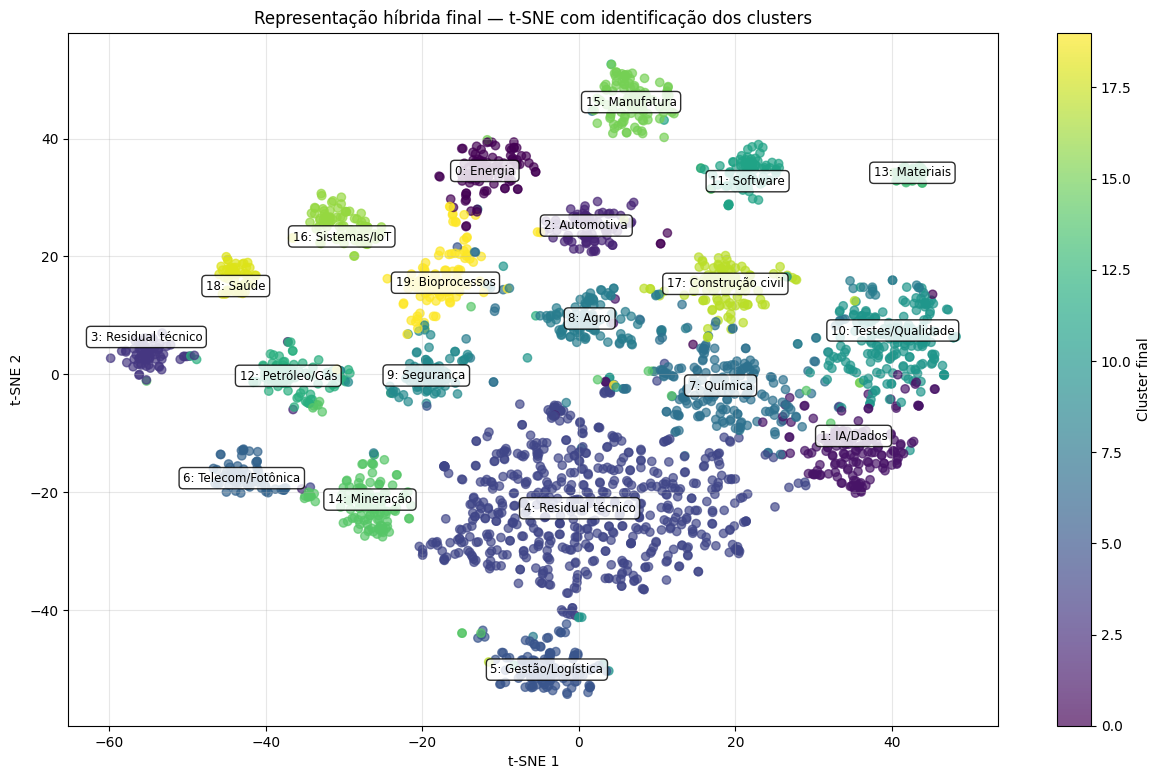

In [66]:
# ============================================================
# t-SNE FINAL COM IDENTIFICAÇÃO DOS CLUSTERS
# ============================================================

plt.figure(figsize=(15, 9))

scatter = plt.scatter(
    df_textos_filtrado["tsne_final_1"],
    df_textos_filtrado["tsne_final_2"],
    c=df_textos_filtrado["cluster_final"],
    alpha=0.68
)

# Ajustes manuais para reduzir sobreposição de rótulos.
ajustes_rotulos_tsne_final = {
    3: (0, 3),
    1: (0, 2),
    11: (0, -2),
    16: (0, -2),
    10: (0, 2),
    18: (0, -2)
}

for cluster_id in sorted(df_textos_filtrado["cluster_final"].unique()):
    df_cluster = df_textos_filtrado[
        df_textos_filtrado["cluster_final"] == cluster_id
    ]

    x_mediano = df_cluster["tsne_final_1"].median()
    y_mediano = df_cluster["tsne_final_2"].median()

    dx, dy = ajustes_rotulos_tsne_final.get(cluster_id, (0, 0))

    nome_curto = nomes_clusters_finais_curto.get(
        cluster_id,
        f"Cluster {cluster_id}"
    )

    texto_rotulo = f"{cluster_id}: {nome_curto}"

    plt.text(
        x_mediano + dx,
        y_mediano + dy,
        texto_rotulo,
        fontsize=8.5,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            alpha=0.82
        )
    )

plt.title("Representação híbrida final — t-SNE com identificação dos clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster final")

plt.show()

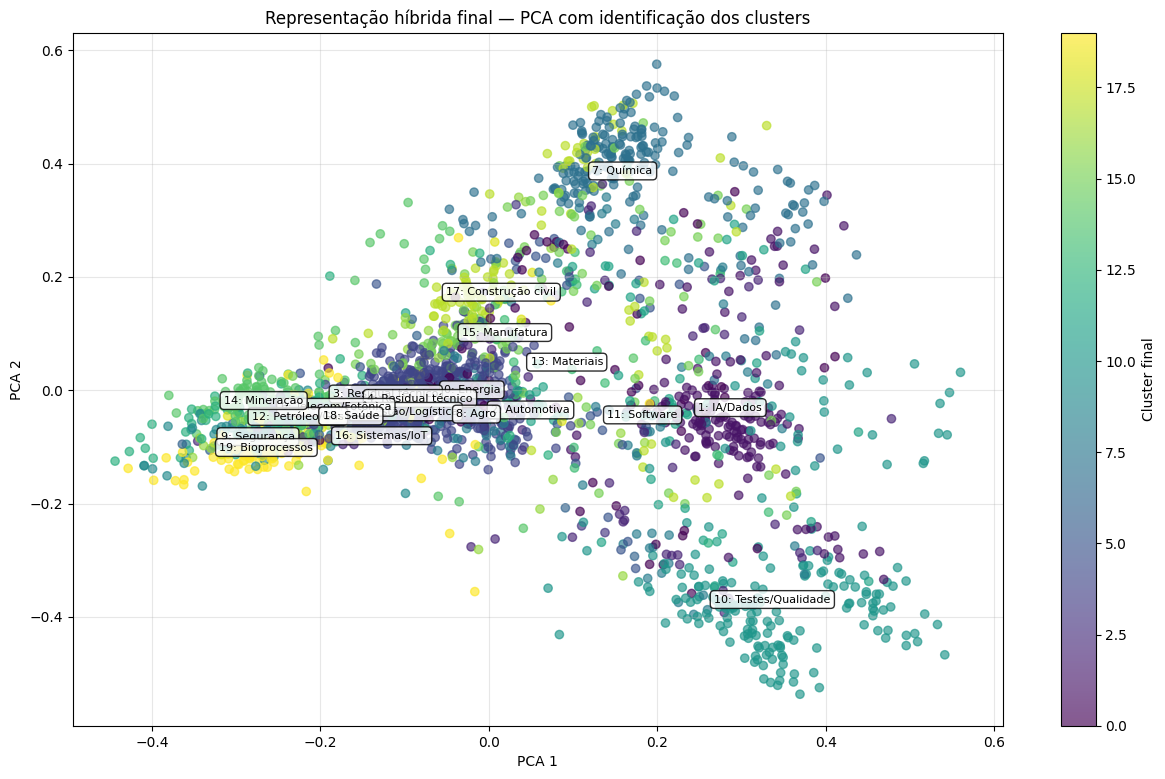

In [67]:
# ============================================================
# PCA FINAL COM IDENTIFICAÇÃO DOS CLUSTERS
# ============================================================

plt.figure(figsize=(15, 9))

scatter = plt.scatter(
    df_textos_filtrado["pca_final_1"],
    df_textos_filtrado["pca_final_2"],
    c=df_textos_filtrado["cluster_final"],
    alpha=0.65
)

ajustes_rotulos_pca_final = {
    3: (0, 0.025),
    1: (0, 0.025),
    11: (0, -0.025),
    16: (0, -0.025)
}

for cluster_id in sorted(df_textos_filtrado["cluster_final"].unique()):
    df_cluster = df_textos_filtrado[
        df_textos_filtrado["cluster_final"] == cluster_id
    ]

    x_mediano = df_cluster["pca_final_1"].median()
    y_mediano = df_cluster["pca_final_2"].median()

    dx, dy = ajustes_rotulos_pca_final.get(cluster_id, (0, 0))

    nome_curto = nomes_clusters_finais_curto.get(
        cluster_id,
        f"Cluster {cluster_id}"
    )

    texto_rotulo = f"{cluster_id}: {nome_curto}"

    plt.text(
        x_mediano + dx,
        y_mediano + dy,
        texto_rotulo,
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            alpha=0.82
        )
    )

plt.title("Representação híbrida final — PCA com identificação dos clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster final")

plt.show()

# 26. Distribuição dos clusters finais

Agora vamos observar a quantidade de textos em cada cluster final.

Essa análise é importante porque permite identificar:

- clusters muito grandes;
- clusters muito pequenos;
- equilíbrio geral da clusterização;
- peso relativo do cluster residual.

In [68]:
# ============================================================
# DISTRIBUIÇÃO FINAL DOS CLUSTERS
# ============================================================

df_distribuicao_clusters_final = (
    df_textos_filtrado["nome_cluster_final"]
    .value_counts()
    .reset_index()
)

df_distribuicao_clusters_final.columns = [
    "nome_cluster",
    "quantidade_textos"
]

df_distribuicao_clusters_final = df_distribuicao_clusters_final.sort_values(
    by="quantidade_textos",
    ascending=False
)

display(df_distribuicao_clusters_final)

,nome_cluster,quantidade_textos
0,Projetos técnico-operacionais gerais e rotas t...,667
1,"Química, polímeros, revestimentos e formulações",211
2,"Metrologia, testes, validação e qualidade",205
3,"IA, ciência de dados e visão computacional",166
4,"Mineração, siderurgia e beneficiamento mineral",138
5,"Agro, alimentos e fertilizantes",133
6,"Gestão, logística e negócios digitais",124
7,"Bioprocessos, bioativos e fermentação",118
8,Construção civil e materiais de construção,118
9,"Manufatura, produção operacional e indústria 4.0",112


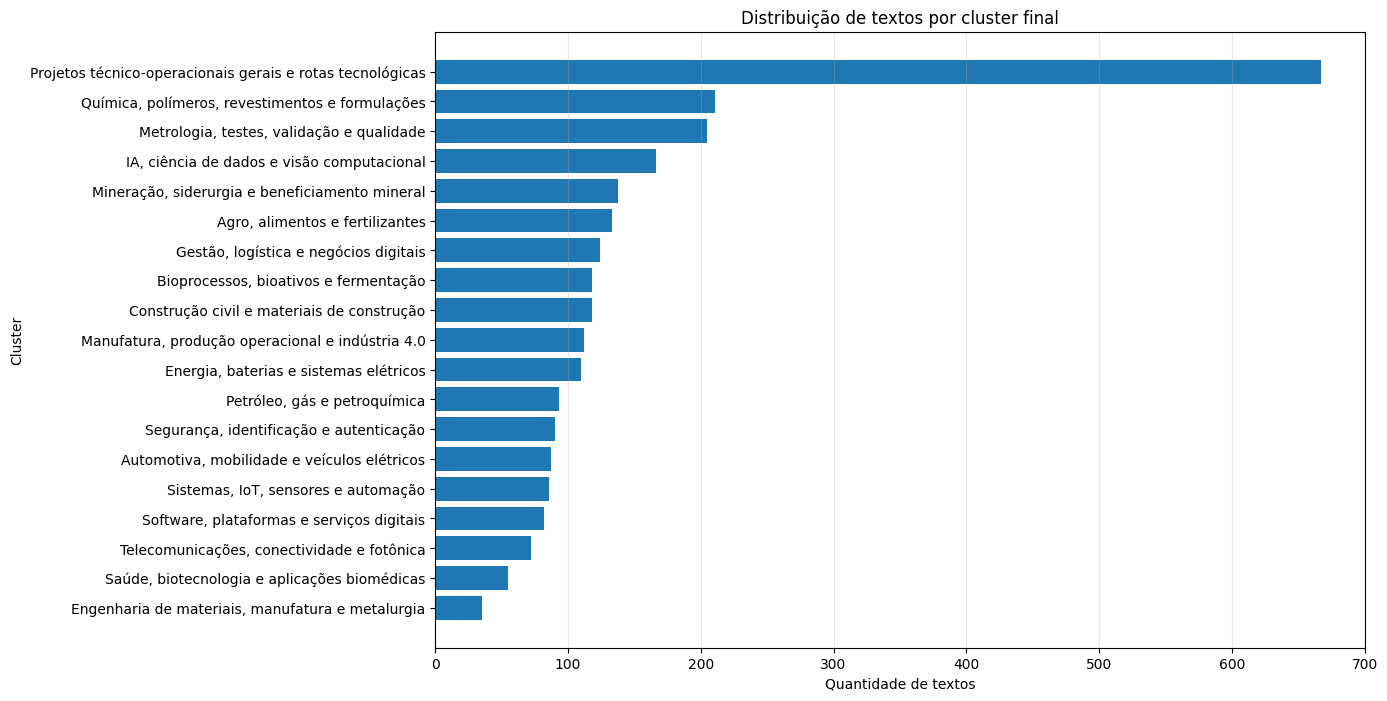

In [69]:
# ============================================================
# GRÁFICO DE DISTRIBUIÇÃO DOS CLUSTERS
# ============================================================

df_plot_distribuicao_final = df_distribuicao_clusters_final.sort_values(
    by="quantidade_textos",
    ascending=True
)

plt.figure(figsize=(12, 8))

plt.barh(
    df_plot_distribuicao_final["nome_cluster"],
    df_plot_distribuicao_final["quantidade_textos"]
)

plt.title("Distribuição de textos por cluster final")
plt.xlabel("Quantidade de textos")
plt.ylabel("Cluster")
plt.grid(True, axis="x", alpha=0.3)

plt.show()

# 27. Identificação do cluster residual

Mesmo após o refinamento das labels, ainda permaneceu um cluster residual.

Esse grupo concentra textos com linguagem mais genérica, curta ou transversal.

Na versão final, o cluster residual foi nomeado como:

**Projetos técnico-operacionais gerais e rotas tecnológicas**

Ele não representa necessariamente uma falha do modelo. Em vez disso, indica que parte dos projetos possui descrições que não acionam claramente nenhuma área temática específica.

In [70]:
# ============================================================
# IDENTIFICAÇÃO DO CLUSTER RESIDUAL FINAL
# ============================================================

cluster_residual_final = int(
    df_cobertura_ner_clusters_final
    .sort_values(
        by=[
            "percentual_sem_entidade_ner",
            "quantidade_textos"
        ],
        ascending=[False, False]
    )
    .iloc[0]["cluster_final"]
)

qtd_residual_final = int(
    df_cobertura_ner_clusters_final[
        df_cobertura_ner_clusters_final["cluster_final"] == cluster_residual_final
    ]["quantidade_textos"].iloc[0]
)

print("Cluster residual final:")
print(cluster_residual_final)

print("\nNome:")
print(nomes_clusters_finais.get(cluster_residual_final))

print("\nQuantidade de textos:")
print(qtd_residual_final)

print("\nCobertura NER do cluster residual:")
display(
    df_cobertura_ner_clusters_final[
        df_cobertura_ner_clusters_final["cluster_final"] == cluster_residual_final
    ]
)

print("\nTermos principais do cluster residual:")
display(
    df_tfidf_clusters_final[
        df_tfidf_clusters_final["cluster"] == cluster_residual_final
    ].head(25)
)

Cluster residual final:
4

Nome:
Projetos técnico-operacionais gerais e rotas tecnológicas

Quantidade de textos:
599

Cobertura NER do cluster residual:


,cluster_final,quantidade_textos,textos_com_entidade_ner,media_entidades_por_texto,textos_sem_entidade_ner,percentual_com_entidade_ner,percentual_sem_entidade_ner
4,4,599,0,0.0,599,0.0,100.0



Termos principais do cluster residual:


,cluster,posicao,termo,peso_tfidf_medio
100,4,1,sistema,0.034374
101,4,2,producao,0.018372
102,4,3,sistemas,0.015249
103,4,4,prototipo,0.014923
104,4,5,controle,0.012733
105,4,6,componentes,0.011740
106,4,7,plataforma,0.011281
107,4,8,avaliacao,0.011230
108,4,9,solucoes,0.010778
109,4,10,tem,0.009888


In [71]:
# ============================================================
# AJUSTE DE NOME DO CLUSTER RESIDUAL
# ============================================================

# Como o número dos clusters pode mudar entre execuções, o nome do cluster residual
# é definido dinamicamente a partir da cobertura do NER.
nomes_clusters_finais[cluster_residual_final] = (
    "Projetos técnico-operacionais gerais e rotas tecnológicas"
)

nomes_clusters_finais_curto[cluster_residual_final] = (
    "Residual técnico"
)

df_textos_filtrado["nome_cluster_final"] = (
    df_textos_filtrado["cluster_final"]
    .map(nomes_clusters_finais)
)

df_textos_filtrado["nome_cluster_final_curto"] = (
    df_textos_filtrado["cluster_final"]
    .map(nomes_clusters_finais_curto)
)

print("Nome do cluster residual ajustado dinamicamente:")
print(cluster_residual_final, "-", nomes_clusters_finais[cluster_residual_final])


Nome do cluster residual ajustado dinamicamente:
4 - Projetos técnico-operacionais gerais e rotas tecnológicas


In [72]:
# ============================================================
# EXEMPLOS DO CLUSTER RESIDUAL FINAL
# ============================================================

df_cluster_residual_final = df_textos_filtrado[
    df_textos_filtrado["cluster_final"] == cluster_residual_final
].copy()

print("Amostra de textos do cluster residual final:")

display(
    df_cluster_residual_final[
        [
            "titulo",
            "qtd_palavras",
            "qtd_entidades_ner_final",
            "texto"
        ]
    ].sample(
        n=min(30, len(df_cluster_residual_final)),
        random_state=RANDOM_STATE
    )
)

Amostra de textos do cluster residual final:


,titulo,qtd_palavras,qtd_entidades_ner_final,texto
600,Desenvolvimento de modelo CFD para simulação d...,21,0,Desenvolvimento de modelo CFD para simulação d...
2118,H2O,5,0,H2O. Desenvolvimento de composição polimérica.
2613,Tolerância a Seca - Fase 4,107,0,Tolerância a Seca - Fase 4. As variações climá...
462,ARM Atabaque,131,0,"ARM Atabaque. Com o ARM, a Atabaque desenvolve..."
846,Desenvolvimentos e Inovações no Sistema de Obs...,59,0,Desenvolvimentos e Inovações no Sistema de Obs...
1345,Telecuidado de idosos,28,0,Telecuidado de idosos. O projeto tem como esco...
102,ENERGY TRACKER,14,0,ENERGY TRACKER. Ferramentas para o acompanhame...
2215,Desenvolvimento de um briquete de alto desempe...,34,0,Desenvolvimento de um briquete de alto desempe...
468,BigData for 3D&GSB,15,0,BigData for 3D&GSB. Principal objetivo a autom...
1842,Desenvolvimento de formulações de polietileno ...,64,0,Desenvolvimento de formulações de polietileno ...


## 27.1 Interpretação do cluster residual

O cluster residual final apresenta termos como:

- produção;
- sistemas;
- protótipo;
- componentes;
- equipamento;
- controle;
- plataforma;
- rota;
- tecnologia;
- otimização.

Esses termos são muito comuns em projetos de pesquisa, desenvolvimento e inovação, mas não indicam necessariamente uma área temática única.

Por isso, esse cluster foi interpretado como um grupo de projetos técnico-operacionais gerais, projetos com descrições pouco específicas ou projetos que combinam várias áreas ao mesmo tempo.

# 28. Tabela final de resultados

A tabela abaixo resume o resultado final da versão V3.1.

Ela reúne:

- quantidade de labels;
- quantidade de entidades extraídas;
- cobertura do NER;
- número de clusters;
- Silhouette Score;
- tamanho do cluster residual.

In [73]:
# ============================================================
# TABELA FINAL DE RESULTADOS
# ============================================================

df_resultado_final = pd.DataFrame([
    {
        "versao_final": "V3.1",
        "quantidade_labels_ner": len(labels_ner_treino_final),
        "quantidade_entidades_extraidas": len(df_entidades_final),
        "textos_com_entidade_ner": int(df_textos_filtrado["possui_entidade_ner_final"].sum()),
        "percentual_textos_com_entidade_ner": round(
            df_textos_filtrado["possui_entidade_ner_final"].mean() * 100,
            2
        ),
        "k_escolhido": int(K_FINAL_ESCOLHIDO),
        "silhouette_score": float(melhor_linha_k_final["silhouette_score"]),
        "cluster_residual": int(cluster_residual_final),
        "tamanho_cluster_residual": int(qtd_residual_final)
    }
])

display(df_resultado_final)

,versao_final,quantidade_labels_ner,quantidade_entidades_extraidas,textos_com_entidade_ner,percentual_textos_com_entidade_ner,k_escolhido,silhouette_score,cluster_residual,tamanho_cluster_residual
0,V3.1,19,6381,2103,77.83,20,0.133795,4,599


# 29. Comparação resumida com a versão anterior

Durante os experimentos, a versão V3 foi usada como principal referência antes da V3.1.

A V3.1 foi escolhida porque melhorou três pontos principais:

1. aumentou a cobertura do NER;
2. aumentou o Silhouette Score;
3. reduziu o cluster residual.

A comparação abaixo resume os resultados obtidos durante os testes.

In [74]:
# ============================================================
# COMPARAÇÃO HISTÓRICA ENTRE V3 E V3.1
# ============================================================

df_comparacao_v3_v31 = pd.DataFrame([
    {
        "versao": "V3",
        "quantidade_labels": 11,
        "quantidade_entidades_extraidas": 4310,
        "textos_com_entidade": 1706,
        "percentual_textos_com_entidade": 63.14,
        "k_escolhido": 11,
        "silhouette_score": 0.109889,
        "cluster_residual": 10,
        "tamanho_cluster_residual": 1016
    },
    {
        "versao": "V3.1",
        "quantidade_labels": len(labels_ner_treino_final),
        "quantidade_entidades_extraidas": len(df_entidades_final),
        "textos_com_entidade": int(df_textos_filtrado["possui_entidade_ner_final"].sum()),
        "percentual_textos_com_entidade": round(
            df_textos_filtrado["possui_entidade_ner_final"].mean() * 100,
            2
        ),
        "k_escolhido": int(K_FINAL_ESCOLHIDO),
        "silhouette_score": float(melhor_linha_k_final["silhouette_score"]),
        "cluster_residual": int(cluster_residual_final),
        "tamanho_cluster_residual": int(qtd_residual_final)
    }
])

df_comparacao_v3_v31["reducao_residual_em_relacao_v3"] = (
    1016 - df_comparacao_v3_v31["tamanho_cluster_residual"]
)

display(df_comparacao_v3_v31)

,versao,quantidade_labels,quantidade_entidades_extraidas,textos_com_entidade,percentual_textos_com_entidade,k_escolhido,silhouette_score,cluster_residual,tamanho_cluster_residual,reducao_residual_em_relacao_v3
0,V3,11,4310,1706,63.14,11,0.109889,10,1016,0
1,V3.1,19,6381,2103,77.83,20,0.133795,4,599,417


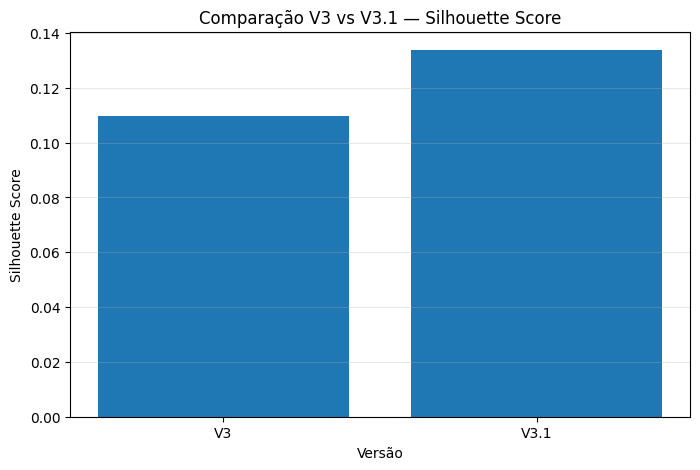

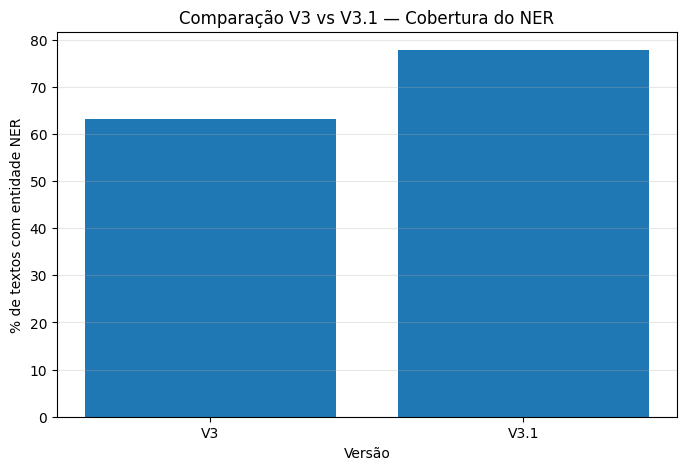

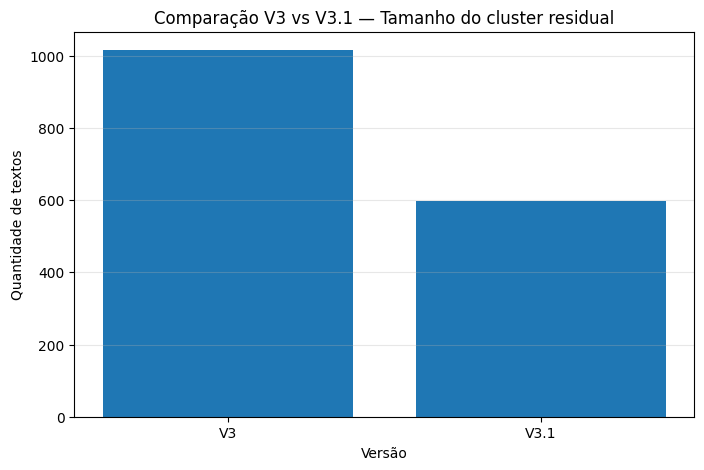

In [75]:
# ============================================================
# GRÁFICOS COMPARATIVOS V3 VS V3.1
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    df_comparacao_v3_v31["versao"],
    df_comparacao_v3_v31["silhouette_score"]
)

plt.title("Comparação V3 vs V3.1 — Silhouette Score")
plt.xlabel("Versão")
plt.ylabel("Silhouette Score")
plt.grid(True, axis="y", alpha=0.3)

plt.show()


plt.figure(figsize=(8, 5))

plt.bar(
    df_comparacao_v3_v31["versao"],
    df_comparacao_v3_v31["percentual_textos_com_entidade"]
)

plt.title("Comparação V3 vs V3.1 — Cobertura do NER")
plt.xlabel("Versão")
plt.ylabel("% de textos com entidade NER")
plt.grid(True, axis="y", alpha=0.3)

plt.show()


plt.figure(figsize=(8, 5))

plt.bar(
    df_comparacao_v3_v31["versao"],
    df_comparacao_v3_v31["tamanho_cluster_residual"]
)

plt.title("Comparação V3 vs V3.1 — Tamanho do cluster residual")
plt.xlabel("Versão")
plt.ylabel("Quantidade de textos")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

## 29.1 Decisão analítica

A versão V3.1 foi adotada como resultado final porque apresentou o melhor equilíbrio entre métrica e interpretabilidade.

Em relação à V3, a V3.1:

- aumentou o número de entidades temáticas extraídas;
- aumentou a cobertura do NER;
- aumentou o Silhouette Score;
- reduziu o cluster residual;
- separou melhor áreas que antes estavam misturadas;
- permitiu identificar clusters mais específicos, como telecomunicações, metrologia, mineração, bioprocessos, software e gestão/logística.

A principal desvantagem da V3.1 é o aumento da complexidade, pois ela usa 19 labels e 20 clusters.

Mesmo assim, para o objetivo exploratório deste trabalho, a V3.1 foi considerada a melhor solução.

# 30. Limitações da solução final

Apesar dos bons resultados obtidos com a V3.1, a solução final ainda possui limitações importantes.

Essas limitações são relevantes porque mostram que o objetivo do projeto não é criar uma classificação perfeita e definitiva, mas sim uma ferramenta exploratória para organização temática dos textos.

## 30.1 Labels construídas de forma semiautomática

As labels temáticas foram refinadas por meio de análise exploratória, auditoria dos clusters e revisão dos termos de referência.

No entanto, o conjunto de treinamento do NER foi construído de forma semiautomática, com base na busca de termos nos textos.

Isso permitiu criar rapidamente um modelo funcional, mas não substitui uma anotação manual feita por especialistas.

Portanto, as métricas do NER devem ser interpretadas como uma avaliação da capacidade do modelo de aprender os padrões definidos pelas labels, e não como uma validação definitiva sobre categorias reais dos projetos.

## 30.2 Sobreposição natural entre áreas

A base analisada contém projetos científicos e tecnológicos interdisciplinares.

Por isso, muitos projetos podem pertencer naturalmente a mais de uma área.

Exemplos:

- inteligência artificial aplicada à saúde;
- sensores aplicados ao agronegócio;
- materiais aplicados ao petróleo;
- software aplicado à logística;
- energia aplicada à mobilidade elétrica;
- bioprocessos aplicados à indústria de alimentos.

Essa sobreposição dificulta a criação de clusters perfeitamente separados.

## 30.3 Presença de cluster residual

Mesmo após o refinamento das labels, ainda permaneceu um cluster residual.

Esse cluster foi nomeado como:

**Projetos técnico-operacionais gerais e rotas tecnológicas**

Ele reúne textos com termos genéricos, como produção, sistema, protótipo, rota, tecnologia, plataforma, controle e otimização.

Esses termos aparecem com frequência em projetos de pesquisa e desenvolvimento, mas não indicam uma área temática específica.

Por isso, o cluster residual não deve ser visto apenas como erro do modelo. Ele também reflete a existência de textos curtos, genéricos, transversais ou pouco informativos.

## 30.4 Escolha do número de clusters

O KMeans exige que o número de clusters seja definido previamente.

Neste projeto, a versão final utilizou `k = 20`.

Essa escolha foi baseada em:

- Silhouette Score;
- tamanho dos clusters;
- redução do cluster residual;
- interpretabilidade dos agrupamentos;
- comparação com versões anteriores.

Ainda assim, outros valores de `k` poderiam gerar agrupamentos diferentes.

Por isso, a escolha de `k = 20` deve ser entendida como uma decisão analítica, e não como uma verdade única sobre a estrutura da base.

## 30.5 Métricas quantitativas com interpretação cautelosa

O Silhouette Score da versão final melhorou em relação à V3.

No entanto, o valor absoluto do Silhouette ainda não é alto.

Isso é esperado em bases textuais reais, interdisciplinares e com textos de tamanhos variados.

Nesses casos, a avaliação não deve depender apenas da métrica numérica.

Por isso, a decisão final considerou também:

- termos principais dos clusters;
- entidades NER dominantes;
- títulos representativos;
- cobertura do NER;
- visualização t-SNE;
- coerência temática dos agrupamentos.

# 31. Possíveis melhorias futuras

A versão V3.1 foi escolhida como solução final deste notebook, mas algumas melhorias podem ser feitas em trabalhos futuros.

## 31.1 Revisão manual do conjunto de treinamento

Uma melhoria importante seria revisar manualmente uma amostra das entidades usadas no treinamento do NER.

Cada exemplo poderia ser classificado como:

- correto;
- incorreto;
- duvidoso.

Isso permitiria medir melhor a qualidade das labels e reduzir ruídos no treinamento.

## 31.2 Criação de uma base gold standard

Uma etapa futura mais robusta seria criar uma base anotada manualmente por especialistas.

Essa base poderia ser usada para avaliar o NER com mais segurança.

Com uma base gold standard, seria possível medir com mais precisão:

- acertos reais;
- falsos positivos;
- falsos negativos;
- confusões entre labels;
- qualidade das entidades extraídas.

## 31.3 Teste de outros algoritmos de clusterização

Neste projeto, foi usado KMeans.

Em trabalhos futuros, outros métodos poderiam ser testados, como:

- clustering hierárquico;
- Gaussian Mixture Models;
- UMAP + HDBSCAN;
- BERTopic.

Esses métodos podem lidar melhor com clusters de tamanhos diferentes e com textos que ficam entre várias áreas.

## 31.4 Teste de sentence embeddings

Neste notebook, os embeddings foram gerados com BERTimbau usando mean pooling.

Uma melhoria futura seria testar modelos próprios para embeddings de sentenças.

Esses modelos podem representar melhor textos completos e melhorar a qualidade da clusterização.

## 31.5 Refinamento das labels menores

Algumas labels da V3.1 possuem menor quantidade de exemplos.

A principal delas é:

- segurança, identificação e autenticação.

Essa label gerou um cluster pequeno e poderia ser refinada futuramente com mais termos, mais exemplos ou revisão manual.

Outras labels que também poderiam ser revisadas são:

- gestão, logística e negócios;
- manufatura e produção operacional;
- metrologia, testes e qualidade.

# 32. Conclusão final

Este projeto desenvolveu uma metodologia para clusterização temática de projetos científicos e tecnológicos a partir de títulos e descrições públicas.

A solução final combinou:

- preparação textual;
- análise exploratória com TF-IDF;
- criação de labels temáticas;
- treinamento de NER personalizado com spaCy;
- geração de embeddings com BERTimbau;
- redução dimensional com PCA e SVD;
- representação híbrida com BERTimbau, TF-IDF e NER;
- clusterização com KMeans;
- interpretação dos clusters com termos, entidades e títulos representativos.

A principal contribuição do projeto foi mostrar que a combinação entre embeddings semânticos e conhecimento de domínio via NER melhora a interpretabilidade dos clusters.

A versão final, V3.1, foi escolhida porque apresentou o melhor equilíbrio entre desempenho quantitativo e interpretação qualitativa.

## 32.1 Principais resultados da V3.1

A versão final apresentou os seguintes resultados:

- 19 labels temáticas;
- 6611 entidades extraídas pelo NER;
- 79,68% dos textos com pelo menos uma entidade NER;
- 20 clusters finais;
- Silhouette Score de aproximadamente 0,135;
- redução do cluster residual de 1016 textos na V3 para 549 textos na V3.1.

A redução do cluster residual foi um dos principais avanços da versão final.

Além disso, a V3.1 conseguiu separar áreas que antes ficavam misturadas, como:

- software e plataformas digitais;
- telecomunicações e fotônica;
- metrologia, testes e qualidade;
- mineração e siderurgia;
- bioprocessos e fermentação;
- gestão e logística;
- manufatura e indústria 4.0.

## 32.2 Interpretação final

A clusterização final não deve ser entendida como uma classificação definitiva dos projetos.

Em vez disso, ela funciona como uma ferramenta exploratória para identificar padrões temáticos em uma base interdisciplinar.

Os clusters ajudam a organizar a base, revelar áreas dominantes, encontrar grupos tecnológicos específicos e destacar textos que ainda permanecem genéricos ou transversais.

Para o objetivo deste trabalho, a V3.1 foi considerada a melhor versão obtida.

# 33. Salvamento dos resultados finais

Nesta etapa, salvamos os principais resultados gerados pelo notebook.

Serão salvos:

- tabela de resultado final;
- comparação V3 vs V3.1;
- resumo dos clusters nomeados;
- base final com cluster atribuído;
- entidades extraídas pelo NER;
- cobertura do NER por cluster;
- resultados do KMeans;
- termos TF-IDF por cluster;
- títulos representativos;
- features híbridas finais;
- modelo NER final;
- objetos auxiliares do pipeline.

Os arquivos serão salvos no diretório `/kaggle/working/resultados_finais_v31`.

In [76]:
# ============================================================
# IMPORTS PARA SALVAMENTO
# ============================================================

import json
import joblib

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Diretório de saída:")
print(OUTPUT_DIR)

Diretório de saída:
/kaggle/working/resultados_finais_v31


In [77]:
# ============================================================
# SALVAMENTO DAS TABELAS PRINCIPAIS
# ============================================================

df_resultado_final.to_csv(
    os.path.join(OUTPUT_DIR, "resultado_final_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_comparacao_v3_v31.to_csv(
    os.path.join(OUTPUT_DIR, "comparacao_v3_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_resumo_clusters_final_nomeado.to_csv(
    os.path.join(OUTPUT_DIR, "resumo_clusters_v31_nomeado.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_distribuicao_clusters_final.to_csv(
    os.path.join(OUTPUT_DIR, "distribuicao_clusters_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_textos_filtrado.to_csv(
    os.path.join(OUTPUT_DIR, "base_textos_com_clusters_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_entidades_final.to_csv(
    os.path.join(OUTPUT_DIR, "entidades_extraidas_ner_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_cobertura_ner_clusters_final.to_csv(
    os.path.join(OUTPUT_DIR, "cobertura_ner_clusters_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_resultados_kmeans_final.to_csv(
    os.path.join(OUTPUT_DIR, "resultados_kmeans_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_tfidf_clusters_final.to_csv(
    os.path.join(OUTPUT_DIR, "tfidf_medio_clusters_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_titulos_representativos_final.to_csv(
    os.path.join(OUTPUT_DIR, "titulos_representativos_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_entidades_por_cluster_final.to_csv(
    os.path.join(OUTPUT_DIR, "entidades_por_cluster_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_metricas_por_label_final.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_ner_por_label_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_resumo_cobertura_ner_final.to_csv(
    os.path.join(OUTPUT_DIR, "resumo_cobertura_ner_v31.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("Tabelas principais salvas.")

Tabelas principais salvas.


In [78]:
# ============================================================
# SALVAMENTO DAS FEATURES E OBJETOS DO PIPELINE
# ============================================================

np.save(
    os.path.join(OUTPUT_DIR, "features_hibridas_final_norm.npy"),
    features_hibridas_final_norm
)

np.save(
    os.path.join(OUTPUT_DIR, "embeddings_bert_final.npy"),
    embeddings_bert_final
)

joblib.dump(
    vectorizer_tfidf_final,
    os.path.join(OUTPUT_DIR, "vectorizer_tfidf_final.joblib")
)

joblib.dump(
    svd_tfidf_final,
    os.path.join(OUTPUT_DIR, "svd_tfidf_final.joblib")
)

joblib.dump(
    pca_bert_final,
    os.path.join(OUTPUT_DIR, "pca_bert_final.joblib")
)

joblib.dump(
    scaler_bert_final,
    os.path.join(OUTPUT_DIR, "scaler_bert_final.joblib")
)

joblib.dump(
    scaler_tfidf_final,
    os.path.join(OUTPUT_DIR, "scaler_tfidf_final.joblib")
)

joblib.dump(
    scaler_ner_final,
    os.path.join(OUTPUT_DIR, "scaler_ner_final.joblib")
)

joblib.dump(
    kmeans_final,
    os.path.join(OUTPUT_DIR, "kmeans_final_v31.joblib")
)

print("Features e objetos do pipeline salvos.")

Features e objetos do pipeline salvos.


In [79]:
# ============================================================
# SALVAMENTO DAS LABELS E NOMES DOS CLUSTERS
# ============================================================

with open(
    os.path.join(OUTPUT_DIR, "labels_ner_treino_v31.json"),
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        labels_ner_treino_final,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

with open(
    os.path.join(OUTPUT_DIR, "nomes_clusters_finais.json"),
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        nomes_clusters_finais,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

with open(
    os.path.join(OUTPUT_DIR, "nomes_clusters_finais_curto.json"),
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        nomes_clusters_finais_curto,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

print("Labels e nomes dos clusters salvos.")

Labels e nomes dos clusters salvos.


In [80]:
# ============================================================
# SALVAMENTO DO MODELO NER FINAL
# ============================================================

CAMINHO_MODELO_NER_FINAL = os.path.join(
    OUTPUT_DIR,
    "modelo_ner_final_v31"
)

nlp_ner_final.to_disk(
    CAMINHO_MODELO_NER_FINAL
)

print("Modelo NER final salvo em:")
print(CAMINHO_MODELO_NER_FINAL)

Modelo NER final salvo em:
/kaggle/working/resultados_finais_v31/modelo_ner_final_v31


# 35. Compactação dos resultados

Por fim, vamos compactar a pasta de resultados em um arquivo `.zip`.

Esse arquivo pode ser baixado diretamente pelo Kaggle.

In [81]:
# ============================================================
# COMPACTAÇÃO DOS RESULTADOS FINAIS
# ============================================================

arquivo_zip_final = "/kaggle/working/resultados_finais_v31.zip"

if os.path.exists(arquivo_zip_final):
    os.remove(arquivo_zip_final)

shutil.make_archive(
    base_name=arquivo_zip_final.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR
)

print("Arquivo ZIP final criado:")
print(arquivo_zip_final)

print("\nArquivos salvos no diretório final:")
for arquivo in sorted(os.listdir(OUTPUT_DIR)):
    print("-", arquivo)

Arquivo ZIP final criado:
/kaggle/working/resultados_finais_v31.zip

Arquivos salvos no diretório final:
- base_textos_com_clusters_v31.csv
- cobertura_ner_clusters_v31.csv
- comparacao_v3_v31.csv
- distribuicao_clusters_v31.csv
- embeddings_bert_final.npy
- entidades_extraidas_ner_v31.csv
- entidades_por_cluster_v31.csv
- features_hibridas_final_norm.npy
- kmeans_final_v31.joblib
- labels_ner_treino_v31.json
- metricas_ner_por_label_v31.csv
- modelo_ner_final_v31
- nomes_clusters_finais.json
- nomes_clusters_finais_curto.json
- pca_bert_final.joblib
- resultado_final_v31.csv
- resultados_kmeans_v31.csv
- resumo_clusters_v31_nomeado.csv
- resumo_cobertura_ner_v31.csv
- scaler_bert_final.joblib
- scaler_ner_final.joblib
- scaler_tfidf_final.joblib
- svd_tfidf_final.joblib
- tfidf_medio_clusters_v31.csv
- titulos_representativos_v31.csv
- vectorizer_tfidf_final.joblib


# 36. Encerramento

O notebook final foi concluído.

A versão V3.1 foi adotada como solução final por apresentar o melhor equilíbrio entre:

- cobertura do NER;
- redução do cluster residual;
- aumento do Silhouette Score;
- interpretabilidade dos clusters;
- separação de áreas temáticas específicas.

O resultado final mostra que a combinação de BERTimbau, TF-IDF e NER personalizado é uma estratégia promissora para clusterização temática exploratória de textos científicos e tecnológicos.